# Medical Image Segmentation with Transformers: Swin UNETR on CT Spleen

**Neural Networks final project (Project #3), Shenkar, Year 3 Semester B, 2026. Ori Grossman & Amit Eliya, BSc Software Engineering.**

The brief asked me to take a vision transformer (Swin), use it to segment tumours or organs from CT/MRI, and then use the attention layer to explain the decision. The dataset is the Medical Segmentation Decathlon.

Out of the ten Decathlon tasks I picked Task09 Spleen. It is a binary problem, background versus spleen, on abdominal CT, and it only has 41 labelled volumes, so a single run finishes in about an hour on the lab GPU. BrainTumour, Liver and Hippocampus are bigger and slower, and this assignment is graded on process, on showing what I tried and what failed. A small task let me run four full trainings and actually compare them instead of babysitting one huge run.

The model is MONAI's Swin UNETR: a Swin transformer encoder (shifted-window self-attention, which is linear in the number of tokens instead of quadratic like a plain ViT) on top of a U-Net style convolutional decoder with skip connections. About 62 million parameters.

My best run reaches validation Dice 0.9465. The Swin UNETR paper reports 95.79 and nnU-Net reports 96.34 on this same task, so I land about a point behind them with far less data and compute. One caveat up front, and I come back to it in the conclusions: I tuned every setting on the same 9 validation volumes I then report, and I never held out a separate test set, so all of my numbers are optimistic. The part of this project I learned the most from is the ablation in section 3, where a change I was sure would help, data augmentation, cost me about three and a half Dice points, and I had to build a controlled run to understand why.

The notebook runs top to bottom: a short survey of the related work, then data and preprocessing, the baseline, the four-run hyper-parameter scan, the comparison to published work, the attention-based explanation, and conclusions.

> **הערת הרצה / reproducibility:** the notebook was executed on the Shenkar GPU lab; the code cells point at that filesystem (`/home/ori.grossman/...`) and depend on its CUDA, the MSD Task09 data, and saved checkpoints. It is submitted **with all outputs and figures already saved** — it is the record of the runs, not meant to be re-run elsewhere. The scripts that produced the seed / significance / null-control / occlusion numbers are included below, in this notebook, as cells with their captured lab output — so the notebook is self-contained and no separate scripts are needed.

## Related work: from U-Net to Swin UNETR

Before my own runs, here is the line of work this project sits on, and where my two small additions fit.

Medical image segmentation has been led by the U-Net family since Ronneberger et al. (2015). The original U-Net is an encoder that downsamples and a decoder that upsamples, wired together with skip connections so fine spatial detail survives the bottleneck. It is still the template almost everyone starts from. Cicek et al. (2016) extended it to 3-D with 3D U-Net, and Milletari et al. (2016) did the same idea with V-Net, both so the network can see a whole volume instead of independent slices. The strongest classical version is nnU-Net (Isensee et al., Nature Methods 2021), a U-Net that self-configures its preprocessing, patch size and training schedule per dataset. It is a very hard baseline to beat and it reports 96.34 Dice on this exact Spleen task.

The transformer branch started with ViT (Dosovitskiy et al., ICLR 2021), which cuts an image into patches and runs plain self-attention over them. The catch is that attention cost grows quadratically with the number of tokens, which is painful in 3-D. Swin Transformer (Liu et al., ICCV 2021) fixed that by doing self-attention inside local shifted windows, so cost is linear in the token count and the features come out hierarchical and multi-scale, which suits dense prediction. Several hybrids brought this into segmentation: TransUNet (Chen et al., 2021) puts a transformer in a CNN bottleneck, UNETR (Hatamizadeh et al., WACV 2022) uses a ViT encoder with a conv decoder for 3-D, and Swin UNETR (Hatamizadeh et al., 2022) uses a Swin encoder with a U-Net style decoder. Swin UNETR is the model I use, and its paper reports 95.79 Dice on MSD Spleen.

For the explainability half, the two methods people usually reach for are Grad-CAM (Selvaraju et al., ICCV 2017), a gradient-based saliency map really made for CNNs, and attention roll-out (Abnar & Zuidema, ACL 2020), which composes the attention matrices across all transformer layers into one map. My explanation in section 4 is a lighter single-layer version of the attention idea, and I say in that section why a full roll-out would be sharper.

Where do I add anything. First, the recipes above all just assume you add data augmentation on a small dataset. My run in section 3 shows that on 32 volumes augmentation actually lowered my Dice. The papers above do not report this because they are not compute-starved the way I am. Second, instead of only showing a nice attention overlay like most transformer papers do, I reduce the attention map to a single number, the attention-on-spleen ratio, and report it across all 9 validation cases rather than one hand-picked slide. Neither of these is a strong result on its own, and I flag the limits of both later.

## 1. Data: MSD Task09 Spleen

The data is 41 labelled 3-D CT volumes from the Medical Segmentation Decathlon Spleen task. I split them 32 for training and 9 for validation. Every label is binary, background or spleen. There is no separate test set, which matters for how the numbers should be read and which I come back to in the conclusions.

Getting the files onto the lab machine was already a small fight. MONAI's `download_and_extract` did not persist on the lab's NFS, and `~/Datasets` is a read-only mount, so the download kept vanishing. In the end I streamed the archive down with plain `urllib` into my own writable project folder. Not elegant, but it stayed on disk.

The preprocessing pipeline (MONAI 1.4.0) is a `Compose` of, in order: `LoadImaged`, `EnsureChannelFirstd`, `Orientationd` to RAS so every scan faces the same way, `Spacingd` resampling to 1.5 x 1.5 x 2.0 mm so a voxel means the same physical size across patients, then `ScaleIntensityRanged` with a CT window of -57 to 164 HU (clip and normalise), `CropForegroundd`, and finally `RandCropByPosNegLabeld` to pull 96x96x96 patches.

The -57 to 164 HU window is a standard soft-tissue abdominal window: below -57 is basically air and fat, above 164 is bone and contrast-filled vessels, so clipping to this range throws away the intensities the spleen never occupies and lets the network spend its capacity on the organ instead of learning to ignore ribs. The 96^3 patches are a memory decision. A full CT volume does not fit in GPU memory once you add the autograd graph, and cropping fixed-size patches keeps memory bounded while `RandCropByPosNegLabeld` samples positive and negative regions so most patches are not pure background. That last point comes back in section 4, because the same sampler tends to place the spleen near the centre of the patch.

I run `num_samples=4` with `batch_size=1`, giving 4 patches per optimizer step, and section 2 explains why I could not push that higher. Both sets are wrapped in `CacheDataset` so the deterministic transforms run once and stay in memory, which is a large speedup on repeated epochs and the whole point of choosing a small task.

The figure below is one validation slice with the ground-truth spleen mask overlaid, so I can see the pipeline produces sane input.

In [1]:
import os, site, sys, glob

# --- project folders ---
BASE = "/home/ori.grossman/nn_final"
for sub in ["notebooks", "models", "figures"]:
    os.makedirs(os.path.join(BASE, sub), exist_ok=True)
print("project tree ready under", BASE)

# --- resume: monai path fix + sanity ---
us = site.getusersitepackages()
if us not in sys.path:
    sys.path.insert(0, us)
import monai, torch
print("MONAI:", monai.__version__, "| CUDA:", torch.cuda.is_available(), "|", torch.cuda.get_device_name(0))

DATA_DIR = os.path.join(BASE, "data", "Task09_Spleen")
print("images:", len(glob.glob(DATA_DIR + "/imagesTr/*.nii.gz")),
      "| labels:", len(glob.glob(DATA_DIR + "/labelsTr/*.nii.gz")))

project tree ready under /home/ori.grossman/nn_final


[07/08/2026-11:14:48] [TRT] [W] Functionality provided through tensorrt.plugin module is experimental.
MONAI: 1.4.0 | CUDA: True | NVIDIA L4
images: 41 | labels: 41


In [3]:
import os, glob
from monai.utils import set_determinism
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Orientationd, Spacingd,
    ScaleIntensityRanged, CropForegroundd, RandCropByPosNegLabeld,
)
set_determinism(seed=0)   # reproducibility — matters for the "show your process" section

DATA_DIR = "/home/ori.grossman/nn_final/data/Task09_Spleen"
imgs = sorted(f for f in glob.glob(DATA_DIR + "/imagesTr/*.nii.gz") if not os.path.basename(f).startswith("._"))
lbls = sorted(f for f in glob.glob(DATA_DIR + "/labelsTr/*.nii.gz") if not os.path.basename(f).startswith("._"))
data = [{"image": i, "label": l} for i, l in zip(imgs, lbls)]
train_files, val_files = data[:-9], data[-9:]     # 32 train / 9 val
print(f"total {len(data)} | train {len(train_files)} | val {len(val_files)}")

CT_MIN, CT_MAX = -57, 164        # standard spleen CT intensity window
PIXDIM = (1.5, 1.5, 2.0)         # resample to uniform voxel spacing (mm)
PATCH  = (96, 96, 96)            # 3D patch size — fits the L4 comfortably

train_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"], pixdim=PIXDIM, mode=("bilinear", "nearest")),
    ScaleIntensityRanged(keys=["image"], a_min=CT_MIN, a_max=CT_MAX, b_min=0.0, b_max=1.0, clip=True),
    CropForegroundd(keys=["image", "label"], source_key="image"),
    RandCropByPosNegLabeld(keys=["image", "label"], label_key="label", spatial_size=PATCH,
                           pos=1, neg=1, num_samples=4, image_key="image", image_threshold=0),
])
val_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"], pixdim=PIXDIM, mode=("bilinear", "nearest")),
    ScaleIntensityRanged(keys=["image"], a_min=CT_MIN, a_max=CT_MAX, b_min=0.0, b_max=1.0, clip=True),
    CropForegroundd(keys=["image", "label"], source_key="image"),
])
print("transforms ready")

total 41 | train 32 | val 9
transforms ready


volume shape: (226, 157, 113) | showing slice z = 83


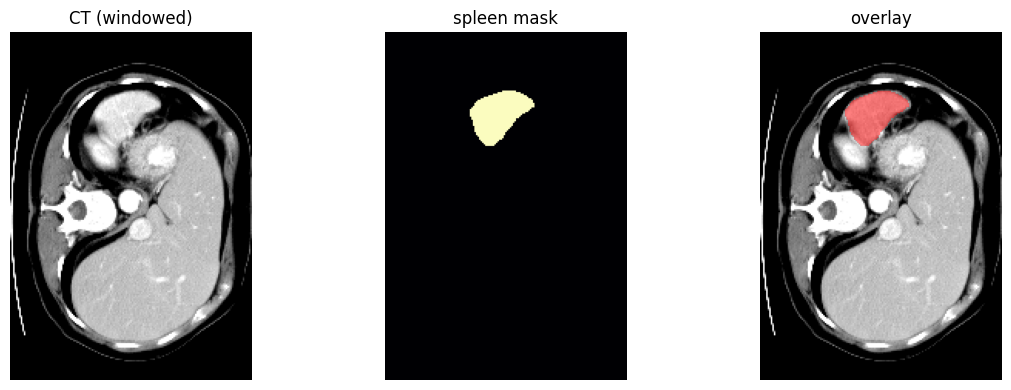

In [3]:
import matplotlib.pyplot as plt
import numpy as np

sample = val_transforms(val_files[0])
img = sample["image"][0].numpy()      # (H, W, D)
lbl = sample["label"][0].numpy()
z = int(np.argmax(lbl.sum(axis=(0, 1))))   # slice with the most spleen
print("volume shape:", img.shape, "| showing slice z =", z)

fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(img[:, :, z], cmap="gray");  ax[0].set_title("CT (windowed)")
ax[1].imshow(lbl[:, :, z], cmap="magma"); ax[1].set_title("spleen mask")
ax[2].imshow(img[:, :, z], cmap="gray")
ax[2].imshow(np.ma.masked_where(lbl[:, :, z] == 0, lbl[:, :, z]), cmap="autumn", alpha=0.5)
ax[2].set_title("overlay")
for a in ax: a.axis("off")
plt.tight_layout(); plt.show()

In [6]:
from monai.data import CacheDataset, DataLoader, list_data_collate
train_ds = CacheDataset(data=train_files, transform=train_transforms, cache_rate=1.0, num_workers=4)
val_ds   = CacheDataset(data=val_files,   transform=val_transforms,   cache_rate=1.0, num_workers=4)
train_loader = DataLoader(train_ds, batch_size=1, shuffle=True, num_workers=4, collate_fn=list_data_collate)
val_loader   = DataLoader(val_ds,   batch_size=1, num_workers=2)
print("loaders ready | patches/step:", 1 * 4)

loaders ready | patches/step: 4


## 2. Baseline: Swin UNETR

The model is `SwinUNETR(img_size=96, in_channels=1, out_channels=2, feature_size=48, use_checkpoint=True)`, which comes out at 62.2M parameters. One input channel because CT is greyscale, two output channels for background and spleen. `use_checkpoint=True` turns on gradient checkpointing, which trades a bit of recompute for a lot less memory, and I needed that trade to fit on one GPU.

Before training I ran a single sanity forward pass. Input `(4,1,96,96,96)` gives output `(4,2,96,96,96)`, initial loss 1.4615, and GPU memory sat at 6.0 GB of 24 GB. Shapes line up and the loss is sane for two classes, so the wiring is correct.

Choices, with reasons:

- **Loss: `DiceCELoss`.** Dice handles the heavy class imbalance (the spleen is a tiny fraction of each patch), and the cross-entropy term keeps the per-voxel gradients well behaved early on when the Dice term is noisy. Using both is the standard MONAI recipe and it converged cleanly.
- **Optimizer: AdamW, lr 1e-4, weight_decay 1e-5.** AdamW because its decoupled weight decay behaves better on transformers than plain Adam's L2. 1e-4 is a standard starting learning rate for AdamW on this kind of model, and the small decay nudges against overfitting on only 32 volumes.
- **AMP mixed precision** (`torch.amp` with a `GradScaler`). This roughly halves activation memory and speeds up the matmuls on the L4. Without it I could not keep even 4 patches per step.
- **Metric: `DiceMetric`, validation via `sliding_window_inference`** (roi 96, overlap 0.5), run every 5 epochs. I validate on full volumes with a sliding window because the model trains on patches but is judged on whole organs, and I validate only every 5 epochs because inference over 9 volumes is not free.

The engineering reality shaped every run. `batch_size=2` (8 patches) OOMs the moment the backward pass and optimizer state land, so I stayed at 4 patches per step. The lab session also dies about every 100 minutes, so I capped each run somewhere between 60 and 100 epochs, about a minute per epoch, and made every run save `best.pth` and `results.json` to disk every 5 epochs. That habit saved me later when exp2 got killed mid-run.

The core hyper-parameters here are not values I searched. `feature_size=48` and the two-channel head are the standard MONAI SwinUNETR configuration for this task, and `lr=1e-4` with `weight_decay=1e-5` are ordinary AdamW starting values. The two settings I might otherwise have swept, batch size and patch size, are pinned by the hardware: `batch_size=2` OOMs and a full volume does not fit, so 4 patches of 96^3 is the largest thing that trains on this 24 GB GPU. Re-searching values that are already standard or already fixed by memory would burn my limited compute for nothing, so my scan in section 3 spends its budget on the training strategy (schedule, warm-up, LR floor, augmentation on or off), the part that was genuinely unknown for a dataset this small.

Baseline result: best val Dice **0.9437 at epoch 60**, about 61.9 minutes, train loss falling from 0.9234 to around 0.21. Two things bug me about it, and they set up section 3. The validation curve is unstable: it dipped to 0.6359 at epoch 10 and 0.7128 at epoch 30 before recovering. And the best score is on the very last epoch, which usually means the model was still improving and I stopped too early.

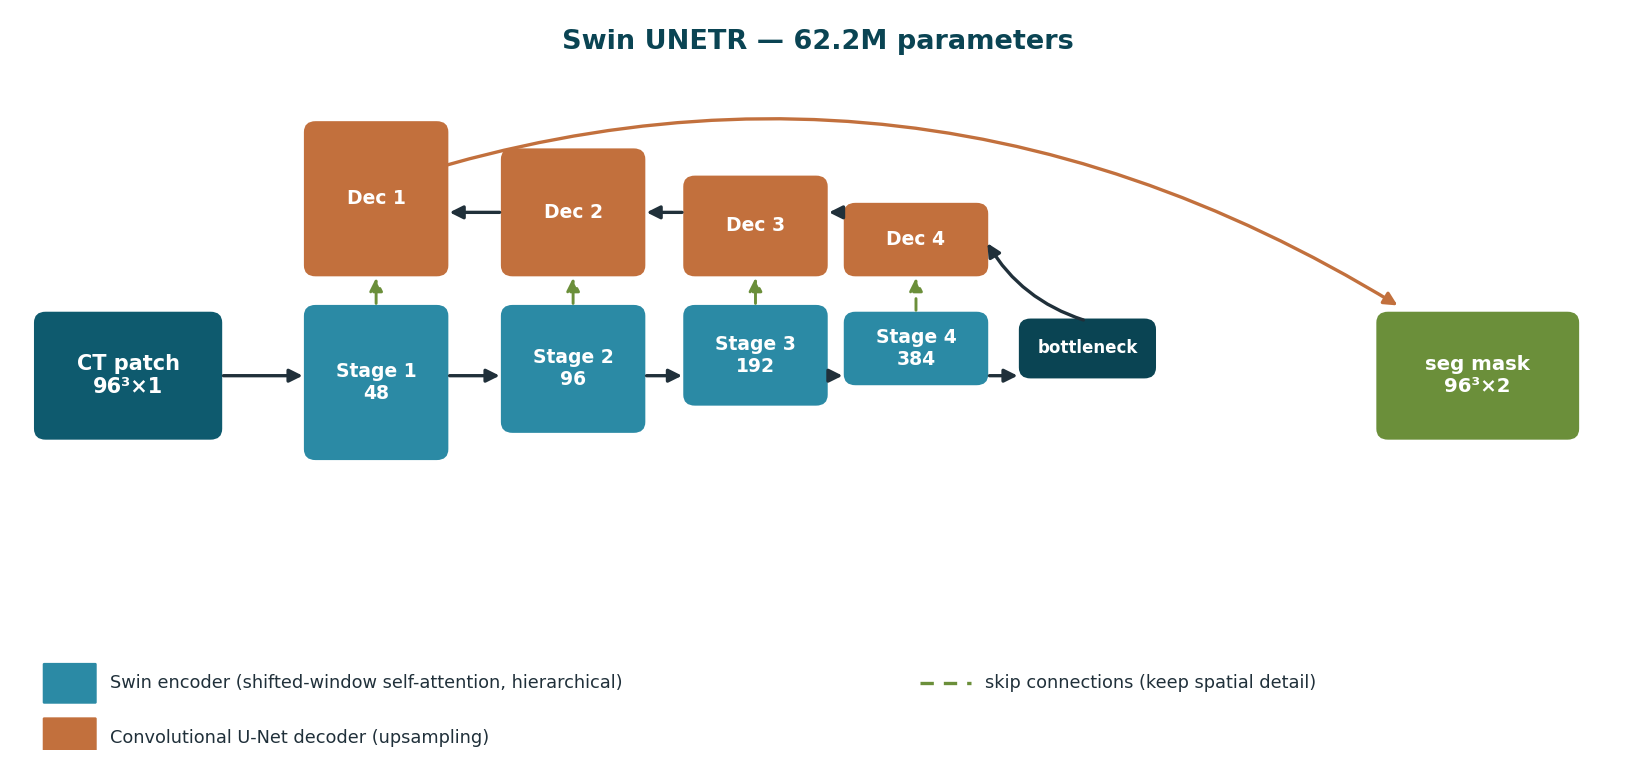

*מבנה ה-Swin UNETR: patch של CT נכנס ל-encoder מסוג Swin (self-attention בחלונות, בכמה סקאלות), עובר bottleneck, ואז decoder קונבולוציוני שמשחזר את המסכה. ה-skip connections (מקווקו) מעבירים פרטים מרחביים מה-encoder ל-decoder.*

In [7]:
import torch
from monai.networks.nets import SwinUNETR
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric

device = torch.device("cuda")
model = SwinUNETR(img_size=(96, 96, 96), in_channels=1, out_channels=2,
                  feature_size=48, use_checkpoint=True).to(device)

loss_fn     = DiceCELoss(to_onehot_y=True, softmax=True)
optimizer   = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
dice_metric = DiceMetric(include_background=False, reduction="mean")
print(f"SwinUNETR params: {sum(p.numel() for p in model.parameters())/1e6:.1f}M")

# one forward+loss pass, mixed precision, to check shapes & memory
model.train()
b = next(iter(train_loader))
x, yv = b["image"].to(device), b["label"].to(device)
with torch.autocast("cuda"):
    out  = model(x)
    loss = loss_fn(out, yv)
print("input:", tuple(x.shape), "-> output:", tuple(out.shape), "| loss:", round(loss.item(), 4))
print(f"GPU mem: {torch.cuda.memory_allocated()/1e9:.1f} GB / "
      f"{torch.cuda.get_device_properties(0).total_memory/1e9:.0f} GB")

SwinUNETR params: 62.2M
input: (4, 1, 96, 96, 96) -> output: (4, 2, 96, 96, 96) | loss: 1.4615
GPU mem: 6.0 GB / 24 GB


In [8]:
import time, torch
from monai.inferers import sliding_window_inference
from monai.transforms import AsDiscrete
from monai.data import decollate_batch

max_epochs, val_interval, roi = 60, 5, (96, 96, 96)
post_pred  = AsDiscrete(argmax=True, to_onehot=2)
post_label = AsDiscrete(to_onehot=2)
scaler     = torch.amp.GradScaler("cuda")
MODEL_DIR  = "/home/ori.grossman/nn_final/models"

best_dice, best_epoch = -1.0, -1
epoch_loss_values, metric_values, metric_epochs = [], [], []

t0 = time.time()
for epoch in range(1, max_epochs + 1):
    model.train()
    epoch_loss, steps = 0.0, 0
    for batch in train_loader:
        x, yv = batch["image"].to(device), batch["label"].to(device)
        optimizer.zero_grad()
        with torch.autocast("cuda"):
            loss = loss_fn(model(x), yv)
        scaler.scale(loss).backward()
        scaler.step(optimizer); scaler.update()
        epoch_loss += loss.item(); steps += 1
    epoch_loss /= steps
    epoch_loss_values.append(epoch_loss)
    msg = f"epoch {epoch:3d}/{max_epochs}  loss {epoch_loss:.4f}"

    if epoch % val_interval == 0:
        model.eval(); dice_metric.reset()
        with torch.no_grad():
            for vb in val_loader:
                vx, vy = vb["image"].to(device), vb["label"].to(device)
                with torch.autocast("cuda"):
                    vout = sliding_window_inference(vx, roi, 4, model, overlap=0.5)
                preds = [post_pred(o)  for o in decollate_batch(vout)]
                labs  = [post_label(o) for o in decollate_batch(vy)]
                dice_metric(y_pred=preds, y=labs)
        dice = dice_metric.aggregate().item()
        metric_values.append(dice); metric_epochs.append(epoch)
        msg += f"   |   val Dice {dice:.4f}"
        if dice > best_dice:
            best_dice, best_epoch = dice, epoch
            torch.save(model.state_dict(), f"{MODEL_DIR}/swinunetr_baseline_best.pth")
            msg += "  ← best (saved)"
    print(msg, flush=True)

print(f"\nDONE in {(time.time()-t0)/60:.1f} min | best Dice {best_dice:.4f} @ epoch {best_epoch}")

epoch   1/60  loss 0.9234
epoch   2/60  loss 0.7007
epoch   3/60  loss 0.6211
epoch   4/60  loss 0.5844
epoch   5/60  loss 0.5407   |   val Dice 0.7708  ← best (saved)
epoch   6/60  loss 0.4931
epoch   7/60  loss 0.4825
epoch   8/60  loss 0.4508
epoch   9/60  loss 0.4344
epoch  10/60  loss 0.4263   |   val Dice 0.6359
epoch  11/60  loss 0.3949
epoch  12/60  loss 0.3729
epoch  13/60  loss 0.3077
epoch  14/60  loss 0.3250
epoch  15/60  loss 0.3109   |   val Dice 0.8410  ← best (saved)
epoch  16/60  loss 0.3422
epoch  17/60  loss 0.2951
epoch  18/60  loss 0.3371
epoch  19/60  loss 0.3260
epoch  20/60  loss 0.3078   |   val Dice 0.8898  ← best (saved)
epoch  21/60  loss 0.3109
epoch  22/60  loss 0.2672
epoch  23/60  loss 0.2687
epoch  24/60  loss 0.2417
epoch  25/60  loss 0.2844   |   val Dice 0.9065  ← best (saved)
epoch  26/60  loss 0.2670
epoch  27/60  loss 0.2910
epoch  28/60  loss 0.2286
epoch  29/60  loss 0.2565
epoch  30/60  loss 0.3019   |   val Dice 0.7128
epoch  31/60  loss 0.266

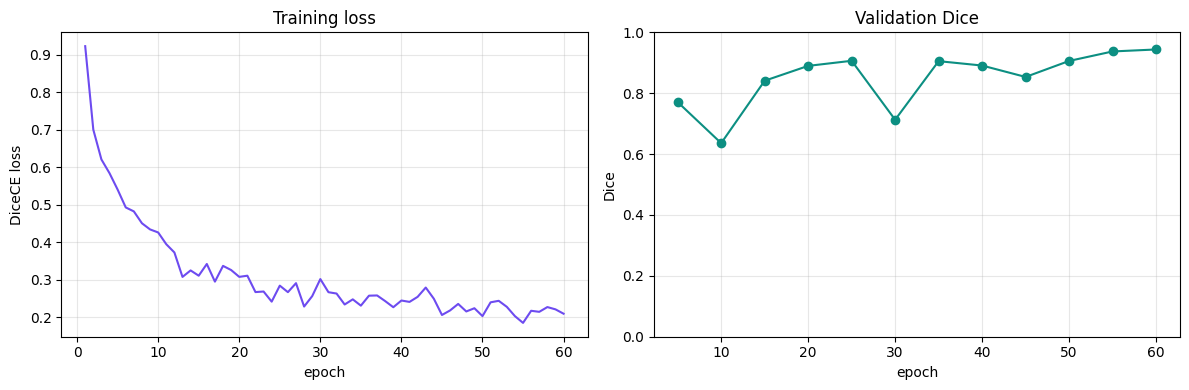

saved -> baseline_learning_curve.png + baseline_results.json


In [2]:
import json, matplotlib.pyplot as plt

# reconstructed from the training log (kernel restarted before they were saved)
epoch_loss_values = [0.9234,0.7007,0.6211,0.5844,0.5407,0.4931,0.4825,0.4508,0.4344,0.4263,
                     0.3949,0.3729,0.3077,0.3250,0.3109,0.3422,0.2951,0.3371,0.3260,0.3078,
                     0.3109,0.2672,0.2687,0.2417,0.2844,0.2670,0.2910,0.2286,0.2565,0.3019,
                     0.2669,0.2633,0.2341,0.2478,0.2310,0.2576,0.2582,0.2431,0.2268,0.2447,
                     0.2410,0.2545,0.2793,0.2494,0.2061,0.2182,0.2356,0.2155,0.2241,0.2031,
                     0.2399,0.2439,0.2278,0.2030,0.1850,0.2173,0.2145,0.2272,0.2211,0.2095]
metric_epochs = [5,10,15,20,25,30,35,40,45,50,55,60]
metric_values = [0.7708,0.6359,0.8410,0.8898,0.9065,0.7128,0.9053,0.8909,0.8534,0.9060,0.9372,0.9437]
best_dice, best_epoch = 0.9437, 60

with open("/home/ori.grossman/nn_final/models/baseline_results.json", "w") as f:
    json.dump({"epoch_loss": epoch_loss_values, "val_epochs": metric_epochs,
               "val_dice": metric_values, "best_dice": best_dice, "best_epoch": best_epoch}, f, indent=2)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(range(1, len(epoch_loss_values)+1), epoch_loss_values, color="#6d4bf0")
ax[0].set_title("Training loss"); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("DiceCE loss")
ax[1].plot(metric_epochs, metric_values, "-o", color="#0c8f82")
ax[1].set_title("Validation Dice"); ax[1].set_xlabel("epoch"); ax[1].set_ylabel("Dice"); ax[1].set_ylim(0, 1)
for a in ax: a.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/home/ori.grossman/nn_final/figures/baseline_learning_curve.png", dpi=120)
plt.show()
print("saved -> baseline_learning_curve.png + baseline_results.json")


## 3. Experiments: what I tried to improve it

The baseline worked but the validation curve was jumpy (those dips to 0.64 and 0.71) and the best number landed on the final epoch, so it looked undertrained. I wanted to make training both smoother and, if I could, a bit more accurate.

The scan does not touch the architecture or optimizer values: they are already fixed (section 2 explains they are the standard SwinUNETR/AdamW config, and batch and patch size are pinned by the 24 GB VRAM limit), so I do not re-search them. I search the training strategy, the part I actually did not know for a 32-volume set.

My hypothesis going in was that a cosine learning-rate schedule with a linear warm-up would tame the instability, and that data augmentation would give the network more variety and push accuracy up. Warm-up because transformers are touchy in the first few hundred steps and a linear ramp stops the early gradients from throwing the weights around. Cosine decay because a smooth ride down to a small learning rate tends to settle into a flatter minimum than a fixed rate. Augmentation because with only 32 volumes I was worried about overfitting and the textbook fix is more effective data.

I made a mess of the first run, and it is exactly the kind of mistake I should own. In exp1 I changed three things at once: the schedule, the warm-up, and the augmentation. When the result came back worse I could not say which of the three did it. The rest of this section is me untangling that one variable at a time.

The augmentation set was `RandFlip` on all three axes, `RandRotate90`, and `RandShiftIntensity`, applied together as one bundle. Because I never turned them on one at a time, I can only talk about the bundle as a whole, not about any single transform on its own. The scan below is four runs. Baseline is the fixed-LR run with no augmentation. exp1 adds the cosine schedule, a 15-epoch warm-up and augmentation, at 80 epochs. exp2 keeps augmentation but changes three things at once relative to exp1: warm-up cut from 15 to 10, length pushed from 80 to 100, and a learning-rate floor added. exp3 takes exp2's schedule and floor and only drops augmentation, at 70 epochs. So the one truly controlled contrast is exp3 against the baseline, which isolates the schedule, and exp3 against exp1/exp2, which isolates augmentation. One thing to note before the numbers: the runs are not epoch-matched (exp1 is 80 epochs, exp2 is 100, exp3 is 70), because the ~100 minute server death capped each one differently. That weakens the comparison, so for the augmentation contrast specifically I later removed it with an epoch-matched control (exp2 recipe re-run at exactly 70 epochs: 0.8927 vs exp3's 0.9465).

**The four runs at a glance — read the single-variable contrasts off this table.**

| run | schedule | warm-up | LR floor | augmentation | epochs | best Dice |
|---|---|---|---|---|---|---|
| baseline | fixed LR | — | — | none | 60 | 0.9437 |
| exp1 | cosine | 15 | — | **on** | 80 | 0.9088 |
| exp2 | cosine | 10 | 1e-5 | **on** | 100 | 0.9108 |
| exp3 | cosine | 10 | 1e-5 | **none** | 70 | 0.9465 |

exp3 vs baseline (both no augmentation) isolates the schedule — it buys the stable curve. exp3 vs exp2 (both cosine + warm-up + floor) isolates augmentation — the only column that differs is augmentation, and that is the ~3.5-point drop. exp1 changed three columns at once versus the baseline, which is why its fall cannot be pinned on any one of them. The one caveat the table makes visible: the epoch column is not matched (80/100/70), because the ~100-minute server cap stopped each run at a different point.

**Epoch-matched control (run afterwards to remove the one caveat above).** The table's weak point was that exp2 ran 100 epochs and exp3 only 70. I removed it by re-running the exp2 recipe (schedule + warm-up + LR floor + augmentation) at *exactly* 70 epochs, everything else identical to exp3, so the only difference is augmentation on/off. It reached best Dice **0.8927** — at epoch 40, then it plateaued and drifted down, so this is a converged run, not an undertrained one — versus exp3's **0.9465**. At a matched 70-epoch budget, turning augmentation off is worth **~5.4 Dice points**, *larger* than the 3.5 the unmatched exp2 (0.9108 @ 100 ep) suggested, because those extra 30 epochs let the augmented run partially recover. So on this 32-volume set augmentation both slows convergence and caps the final score lower — and controlling the epoch confound made the effect bigger, not smaller. It worked against my conclusion and my conclusion still held.

**Code — the epoch-matched control (exp3 recipe + augmentation, at exactly 70 epochs):**

```python
# identical to the exp3 recipe (cosine + 10ep warm-up + LR floor) — the ONLY change is aug ON
aug = [RandFlipd(keys=["image","label"], prob=0.2, spatial_axis=k) for k in (0,1,2)] + \
      [RandRotate90d(keys=["image","label"], prob=0.2, max_k=3),
       RandShiftIntensityd(keys=["image"], offsets=0.1, prob=0.5)]
train_tf = Compose(base + rand + aug)                 # the exp2 augmentation bundle
model = SwinUNETR(img_size=(96,96,96), in_channels=1, out_channels=2, feature_size=48).cuda()
# ... train 70 epochs with the exp3 schedule, validate every 5, keep best.pth ...
print(f"aug @ 70 ep: best Dice {best:.4f} @ epoch {best_ep}   vs   exp3 (no-aug, 70 ep): 0.9465")
```

```
aug @ 70 ep: best Dice 0.8927 @ epoch 40   vs   exp3 (no-aug, 70 ep): 0.9465
```

**Exp 1: cosine + 15-epoch warm-up + augmentation, 80 epochs.** Best val Dice **0.9088 at epoch 70**.

The curve came out much smoother than the baseline, no more wild dips, which was half of what I wanted. But the score dropped from 0.9437 to 0.9088. That surprised me. I had added augmentation expecting accuracy to climb, and instead the score fell about three and a half points. But this run changed the cosine schedule and warm-up alongside augmentation, so I could not yet pin that drop on augmentation; the clean isolate only comes later, holding the schedule fixed and comparing exp2 (0.9108) with exp3 (0.9465).

My first guess was undertraining. Cosine decays the learning rate toward zero by the end, and the validation Dice was still creeping up at epoch 70 when the LR was already tiny. So the story I told myself was that the model still had room to improve but cosine had starved it of learning rate before it got there. That is testable, which is what exp2 is for. I want to flag again that this run moved three variables at once, so at this point I did not know whether the schedule, the warm-up, or the augmentation caused the drop. I just had a suspect, the LR decay, and a plan to check it.

In [1]:
import os, sys, site, json, time, math, glob
us = site.getusersitepackages()
if us not in sys.path: sys.path.insert(0, us)
import torch, matplotlib.pyplot as plt
from monai.utils import set_determinism
from monai.data import CacheDataset, DataLoader, list_data_collate, decollate_batch
from monai.transforms import (Compose, LoadImaged, EnsureChannelFirstd, Orientationd, Spacingd,
    ScaleIntensityRanged, CropForegroundd, RandCropByPosNegLabeld,
    RandFlipd, RandRotate90d, RandShiftIntensityd, AsDiscrete)
from monai.networks.nets import SwinUNETR
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.inferers import sliding_window_inference

set_determinism(seed=0)
device = torch.device("cuda")
OUT = "/home/ori.grossman/nn_final/experiments/exp1_cosine_aug"
os.makedirs(OUT, exist_ok=True)

DATA_DIR = "/home/ori.grossman/nn_final/data/Task09_Spleen"
imgs = sorted(f for f in glob.glob(DATA_DIR+"/imagesTr/*.nii.gz") if not os.path.basename(f).startswith("._"))
lbls = sorted(f for f in glob.glob(DATA_DIR+"/labelsTr/*.nii.gz") if not os.path.basename(f).startswith("._"))
data = [{"image": i, "label": l} for i, l in zip(imgs, lbls)]
train_files, val_files = data[:-9], data[-9:]

ct_min, ct_max, pixdim, patch = -57, 164, (1.5,1.5,2.0), (96,96,96)
base = [LoadImaged(keys=["image","label"]), EnsureChannelFirstd(keys=["image","label"]),
        Orientationd(keys=["image","label"], axcodes="RAS"),
        Spacingd(keys=["image","label"], pixdim=pixdim, mode=("bilinear","nearest")),
        ScaleIntensityRanged(keys=["image"], a_min=ct_min, a_max=ct_max, b_min=0.0, b_max=1.0, clip=True),
        CropForegroundd(keys=["image","label"], source_key="image")]
train_tf = Compose(base + [
    RandCropByPosNegLabeld(keys=["image","label"], label_key="label", spatial_size=patch,
                           pos=1, neg=1, num_samples=4, image_key="image", image_threshold=0),
    RandFlipd(keys=["image","label"], prob=0.2, spatial_axis=0),
    RandFlipd(keys=["image","label"], prob=0.2, spatial_axis=1),
    RandFlipd(keys=["image","label"], prob=0.2, spatial_axis=2),
    RandRotate90d(keys=["image","label"], prob=0.2, max_k=3),
    RandShiftIntensityd(keys=["image"], offsets=0.1, prob=0.5)])
val_tf = Compose(base)

train_ds = CacheDataset(data=train_files, transform=train_tf, cache_rate=1.0, num_workers=4)
val_ds   = CacheDataset(data=val_files,   transform=val_tf,   cache_rate=1.0, num_workers=4)
train_loader = DataLoader(train_ds, batch_size=1, shuffle=True, num_workers=4, collate_fn=list_data_collate)
val_loader   = DataLoader(val_ds, batch_size=1, num_workers=2)

model = SwinUNETR(img_size=patch, in_channels=1, out_channels=2, feature_size=48, use_checkpoint=True).to(device)
loss_fn = DiceCELoss(to_onehot_y=True, softmax=True)
opt = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
scaler = torch.amp.GradScaler("cuda")
dice_metric = DiceMetric(include_background=False, reduction="mean")
post_pred, post_label = AsDiscrete(argmax=True, to_onehot=2), AsDiscrete(to_onehot=2)

max_epochs, warmup, val_interval = 80, 15, 5
lr_lambda = lambda ep: (ep+1)/warmup if ep < warmup else 0.5*(1+math.cos(math.pi*(ep-warmup)/(max_epochs-warmup)))
sched = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda=lr_lambda)

best_dice, best_epoch, t0 = -1.0, -1, time.time()
hist = {"epoch_loss": [], "val_epochs": [], "val_dice": [], "lr": []}
for epoch in range(1, max_epochs+1):
    model.train(); ep_loss, steps = 0.0, 0
    for b in train_loader:
        x, y = b["image"].to(device), b["label"].to(device)
        opt.zero_grad()
        with torch.autocast("cuda"): loss = loss_fn(model(x), y)
        scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        ep_loss += loss.item(); steps += 1
    ep_loss /= steps; cur_lr = opt.param_groups[0]["lr"]; sched.step()
    hist["epoch_loss"].append(ep_loss); hist["lr"].append(cur_lr)
    line = f"epoch {epoch:3d}/{max_epochs}  loss {ep_loss:.4f}  lr {cur_lr:.2e}"
    if epoch % val_interval == 0:
        model.eval(); dice_metric.reset()
        with torch.no_grad():
            for vb in val_loader:
                vx, vy = vb["image"].to(device), vb["label"].to(device)
                with torch.autocast("cuda"):
                    vout = sliding_window_inference(vx, patch, 4, model, overlap=0.5)
                dice_metric(y_pred=[post_pred(o) for o in decollate_batch(vout)],
                            y=[post_label(o) for o in decollate_batch(vy)])
        dice = dice_metric.aggregate().item()
        hist["val_epochs"].append(epoch); hist["val_dice"].append(dice)
        line += f"  |  val Dice {dice:.4f}"
        if dice > best_dice:
            best_dice, best_epoch = dice, epoch
            torch.save(model.state_dict(), f"{OUT}/best.pth"); line += "  <- best"
        hist["best_dice"], hist["best_epoch"] = best_dice, best_epoch
        json.dump(hist, open(f"{OUT}/results.json","w"), indent=2)
    print(line, flush=True)

hist["best_dice"], hist["best_epoch"], hist["minutes"] = best_dice, best_epoch, (time.time()-t0)/60
json.dump(hist, open(f"{OUT}/results.json","w"), indent=2)
print(f"\nDONE {hist['minutes']:.1f} min | best Dice {best_dice:.4f} @ {best_epoch}")

[07/08/2026-13:02:10] [TRT] [W] Functionality provided through tensorrt.plugin module is experimental.


epoch   1/80  loss 1.3545  lr 6.67e-06
epoch   2/80  loss 1.1010  lr 1.33e-05
epoch   3/80  loss 0.9301  lr 2.00e-05
epoch   4/80  loss 0.8206  lr 2.67e-05
epoch   5/80  loss 0.7642  lr 3.33e-05  |  val Dice 0.3330  <- best
epoch   6/80  loss 0.7119  lr 4.00e-05
epoch   7/80  loss 0.6766  lr 4.67e-05
epoch   8/80  loss 0.6554  lr 5.33e-05
epoch   9/80  loss 0.6331  lr 6.00e-05
epoch  10/80  loss 0.6149  lr 6.67e-05  |  val Dice 0.5741  <- best
epoch  11/80  loss 0.5887  lr 7.33e-05
epoch  12/80  loss 0.5878  lr 8.00e-05
epoch  13/80  loss 0.5584  lr 8.67e-05
epoch  14/80  loss 0.4782  lr 9.33e-05
epoch  15/80  loss 0.5115  lr 1.00e-04  |  val Dice 0.5046
epoch  16/80  loss 0.5254  lr 1.00e-04
epoch  17/80  loss 0.4866  lr 9.99e-05
epoch  18/80  loss 0.4727  lr 9.98e-05
epoch  19/80  loss 0.4631  lr 9.95e-05
epoch  20/80  loss 0.4506  lr 9.91e-05  |  val Dice 0.6943  <- best
epoch  21/80  loss 0.4383  lr 9.85e-05
epoch  22/80  loss 0.4485  lr 9.79e-05
epoch  23/80  loss 0.3832  lr 9.72e

**Exp 2: cosine + 10-epoch warm-up + augmentation + a learning-rate floor of 1e-5, 100 epochs.** Best val Dice **0.9108 at epoch 95**.

I meant this to test the undertraining idea. If exp1 was starved because cosine decayed the learning rate to almost nothing while the model was still climbing, a floor of 1e-5 plus more epochs should let it keep going. That was the intent. But I should be honest that exp2 was not a clean single-variable change over exp1. Going from exp1 to exp2 I shortened the warm-up from 15 to 10, ran 100 epochs instead of 80, and added the floor, all in one run. So this experiment cannot cleanly credit or blame the floor by itself.

Either way, nothing was rescued. 0.9108 against exp1's 0.9088 is +0.002, noise on a 9-volume set. Twenty extra epochs and a learning rate that never fell to zero moved the number by essentially nothing, which was enough to make me drop the undertraining story. What remained was the one big variable common to both exp1 and exp2 and still not isolated: augmentation. exp3 is where I finally isolate it, by holding exp2's schedule and floor fixed and only switching augmentation off.

One practical note: this run got killed at epoch 99 when the lab server did its usual ~100 minute death. It did not matter, because the run self-saves `best.pth` and `results.json` every 5 epochs, so the best checkpoint from epoch 95 was already on disk. I load that saved result here rather than rerun it. This is exactly why I built the save-every-5-epochs habit into every run.

In [1]:
import json
r = json.load(open("/home/ori.grossman/nn_final/experiments/exp2_cosine_aug_floor/results.json"))
print("exp2 best Dice:", r["best_dice"], "@ epoch", r["best_epoch"], "| epochs saved:", len(r["epoch_loss"]))

exp2 best Dice: 0.9108102321624756 @ epoch 95 | epochs saved: 95


**Exp 3: cosine + 10-epoch warm-up + LR floor, NO augmentation, 70 epochs.** Best val Dice **0.9465 at epoch 70**.

Compared to exp2 I changed one thing: I turned augmentation off. Cosine, warm-up and the LR floor stayed. The number went from 0.9108 to 0.9465, and the curve kept the smoothness the schedule had given me. So removing the augmentation bundle clearly helped. It helped even though exp3 ran fewer epochs than exp2 (70 versus 100), which if anything should have favoured exp2, so I am fairly confident the augmentation was hurting rather than the epoch count.

There is a caveat left. The original exp2/exp3 runs were not epoch-matched (100 vs 70), so I re-ran the augmented recipe at exactly 70 epochs as a control (0.8927 vs exp3's 0.9465) to close that. What remains is that the augmentations went in as a bundle (`RandFlip`, `RandRotate90`, `RandShiftIntensity` together), so I can say the bundle hurt but I cannot pin it on any single transform. My best guess is that `RandRotate90` is the main culprit, because rotating abdominal CT by 90 degrees produces body orientations that never occur in a real scan, so I would be forcing the network to be invariant to something it never sees at test time. With only 32 volumes there is also just not much room to pay augmentation's extra cost inside 70 epochs. Both of these are hypotheses. I did not run the per-transform ablation that would confirm them, and I list it as future work.

The two changes did different jobs, and it helps to name which comparison shows each. exp3 against the baseline is the clean one for the schedule: both run without augmentation, so what separates them is only the cosine schedule, warm-up and floor versus a fixed learning rate, and that difference shows up as the smoother curve rather than as accuracy. exp3 against exp1 and exp2 is the comparison that isolates augmentation, and that is where the roughly three-and-a-half-point gap sits. So the schedule bought me stability and augmentation cost me accuracy; they are two separate effects that the earlier runs had tangled together.

On the accuracy itself I am careful: exp3's 0.9465 is above the baseline's 0.9437, but that gap is 0.003 on a 9-volume validation set, well inside the run-to-run noise. I am not claiming exp3 is more accurate than the baseline. What exp3 gives me over the baseline is a stable training curve at the same accuracy, and that stability is why I picked this configuration, not the third decimal place of Dice.

One more limit: exp3's best is again on its final epoch (70), so like the baseline it may still have been improving. I capped it at 70 because of the ~100 minute server death, not because it had converged.

In [4]:
import os, sys, site, json, time, math, glob
us = site.getusersitepackages()
if us not in sys.path: sys.path.insert(0, us)
import torch
from monai.utils import set_determinism
from monai.data import CacheDataset, DataLoader, list_data_collate, decollate_batch
from monai.transforms import (Compose, LoadImaged, EnsureChannelFirstd, Orientationd, Spacingd,
    ScaleIntensityRanged, CropForegroundd, RandCropByPosNegLabeld, AsDiscrete)
from monai.networks.nets import SwinUNETR
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.inferers import sliding_window_inference

set_determinism(seed=0)
device = torch.device("cuda")
OUT = "/home/ori.grossman/nn_final/experiments/exp3_cosine_noaug"
os.makedirs(OUT, exist_ok=True)

DATA_DIR = "/home/ori.grossman/nn_final/data/Task09_Spleen"
imgs = sorted(f for f in glob.glob(DATA_DIR+"/imagesTr/*.nii.gz") if not os.path.basename(f).startswith("._"))
lbls = sorted(f for f in glob.glob(DATA_DIR+"/labelsTr/*.nii.gz") if not os.path.basename(f).startswith("._"))
data = [{"image": i, "label": l} for i, l in zip(imgs, lbls)]
train_files, val_files = data[:-9], data[-9:]

ct_min, ct_max, pixdim, patch = -57, 164, (1.5,1.5,2.0), (96,96,96)
base = [LoadImaged(keys=["image","label"]), EnsureChannelFirstd(keys=["image","label"]),
        Orientationd(keys=["image","label"], axcodes="RAS"),
        Spacingd(keys=["image","label"], pixdim=pixdim, mode=("bilinear","nearest")),
        ScaleIntensityRanged(keys=["image"], a_min=ct_min, a_max=ct_max, b_min=0.0, b_max=1.0, clip=True),
        CropForegroundd(keys=["image","label"], source_key="image")]
train_tf = Compose(base + [RandCropByPosNegLabeld(keys=["image","label"], label_key="label",
    spatial_size=patch, pos=1, neg=1, num_samples=4, image_key="image", image_threshold=0)])
val_tf = Compose(base)

train_ds = CacheDataset(data=train_files, transform=train_tf, cache_rate=1.0, num_workers=4)
val_ds   = CacheDataset(data=val_files,   transform=val_tf,   cache_rate=1.0, num_workers=4)
train_loader = DataLoader(train_ds, batch_size=1, shuffle=True, num_workers=4, collate_fn=list_data_collate)
val_loader   = DataLoader(val_ds, batch_size=1, num_workers=2)

model = SwinUNETR(img_size=patch, in_channels=1, out_channels=2, feature_size=48, use_checkpoint=True).to(device)
loss_fn = DiceCELoss(to_onehot_y=True, softmax=True)
opt = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
scaler = torch.amp.GradScaler("cuda")
dice_metric = DiceMetric(include_background=False, reduction="mean")
post_pred, post_label = AsDiscrete(argmax=True, to_onehot=2), AsDiscrete(to_onehot=2)

max_epochs, warmup, val_interval, floor = 70, 10, 5, 0.1
lr_lambda = lambda ep: (ep+1)/warmup if ep < warmup else floor + (1-floor)*0.5*(1+math.cos(math.pi*(ep-warmup)/(max_epochs-warmup)))
sched = torch.optim.lr_scheduler.LambdaLR(opt, lr_lambda=lr_lambda)

best_dice, best_epoch, t0 = -1.0, -1, time.time()
hist = {"epoch_loss": [], "val_epochs": [], "val_dice": [], "lr": []}
for epoch in range(1, max_epochs+1):
    model.train(); ep_loss, steps = 0.0, 0
    for b in train_loader:
        x, y = b["image"].to(device), b["label"].to(device)
        opt.zero_grad()
        with torch.autocast("cuda"): loss = loss_fn(model(x), y)
        scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        ep_loss += loss.item(); steps += 1
    ep_loss /= steps; cur_lr = opt.param_groups[0]["lr"]; sched.step()
    hist["epoch_loss"].append(ep_loss); hist["lr"].append(cur_lr)
    line = f"epoch {epoch:3d}/{max_epochs}  loss {ep_loss:.4f}  lr {cur_lr:.2e}"
    if epoch % val_interval == 0:
        model.eval(); dice_metric.reset()
        with torch.no_grad():
            for vb in val_loader:
                vx, vy = vb["image"].to(device), vb["label"].to(device)
                with torch.autocast("cuda"):
                    vout = sliding_window_inference(vx, patch, 4, model, overlap=0.5)
                dice_metric(y_pred=[post_pred(o) for o in decollate_batch(vout)],
                            y=[post_label(o) for o in decollate_batch(vy)])
        dice = dice_metric.aggregate().item()
        hist["val_epochs"].append(epoch); hist["val_dice"].append(dice)
        line += f"  |  val Dice {dice:.4f}"
        if dice > best_dice:
            best_dice, best_epoch = dice, epoch
            torch.save(model.state_dict(), f"{OUT}/best.pth"); line += "  <- best"
        hist["best_dice"], hist["best_epoch"] = best_dice, best_epoch
        json.dump(hist, open(f"{OUT}/results.json","w"), indent=2)
    print(line, flush=True)

hist["best_dice"], hist["best_epoch"], hist["minutes"] = best_dice, best_epoch, (time.time()-t0)/60
json.dump(hist, open(f"{OUT}/results.json","w"), indent=2)
print(f"\nDONE {hist['minutes']:.1f} min | best Dice {best_dice:.4f} @ {best_epoch}")

[07/09/2026-09:33:04] [TRT] [W] Functionality provided through tensorrt.plugin module is experimental.


epoch   1/70  loss 1.3055  lr 1.00e-05
epoch   2/70  loss 1.0179  lr 2.00e-05
epoch   3/70  loss 0.8489  lr 3.00e-05
epoch   4/70  loss 0.7466  lr 4.00e-05
epoch   5/70  loss 0.6862  lr 5.00e-05  |  val Dice 0.5719  <- best
epoch   6/70  loss 0.6401  lr 6.00e-05
epoch   7/70  loss 0.5916  lr 7.00e-05
epoch   8/70  loss 0.5712  lr 8.00e-05
epoch   9/70  loss 0.5534  lr 9.00e-05
epoch  10/70  loss 0.5274  lr 1.00e-04  |  val Dice 0.8355  <- best
epoch  11/70  loss 0.5007  lr 1.00e-04
epoch  12/70  loss 0.4643  lr 9.99e-05
epoch  13/70  loss 0.4433  lr 9.98e-05
epoch  14/70  loss 0.3849  lr 9.94e-05
epoch  15/70  loss 0.3986  lr 9.90e-05  |  val Dice 0.8818  <- best
epoch  16/70  loss 0.4216  lr 9.85e-05
epoch  17/70  loss 0.3985  lr 9.78e-05
epoch  18/70  loss 0.3515  lr 9.70e-05
epoch  19/70  loss 0.3678  lr 9.61e-05
epoch  20/70  loss 0.3685  lr 9.51e-05  |  val Dice 0.8779
epoch  21/70  loss 0.3371  lr 9.40e-05
epoch  22/70  loss 0.3548  lr 9.27e-05
epoch  23/70  loss 0.3100  lr 9.14e

**All four runs compared.**

The figure below puts the whole scan in one place. On the left are the validation Dice curves for baseline, exp1 and exp3 across epochs. exp2 shows up only as a single starred point at its best (0.9108 at epoch 95), because I did not keep its full per-epoch curve, only the best value in `results.json`. On the right is a bar chart of the four best Dice scores.

What I read off it: baseline (0.9437) and exp3 (0.9465) sit together at the top, and the two augmentation runs (exp1 0.9088, exp2 0.9108) sit clearly below both. The 0.003 between baseline and exp3 is not a real difference on 9 volumes, so I treat those two as tied on accuracy. What separates them is the shape of the curve, not the final number: the baseline is the spiky line with the dips to 0.64 and 0.71, and exp3 is the smooth one. The gap that is real is the roughly three-and-a-half-point drop the augmentation bundle caused.

(The cell regenerates this from the saved `results.json` files, so it only draws fully when run on the lab where those files live.)

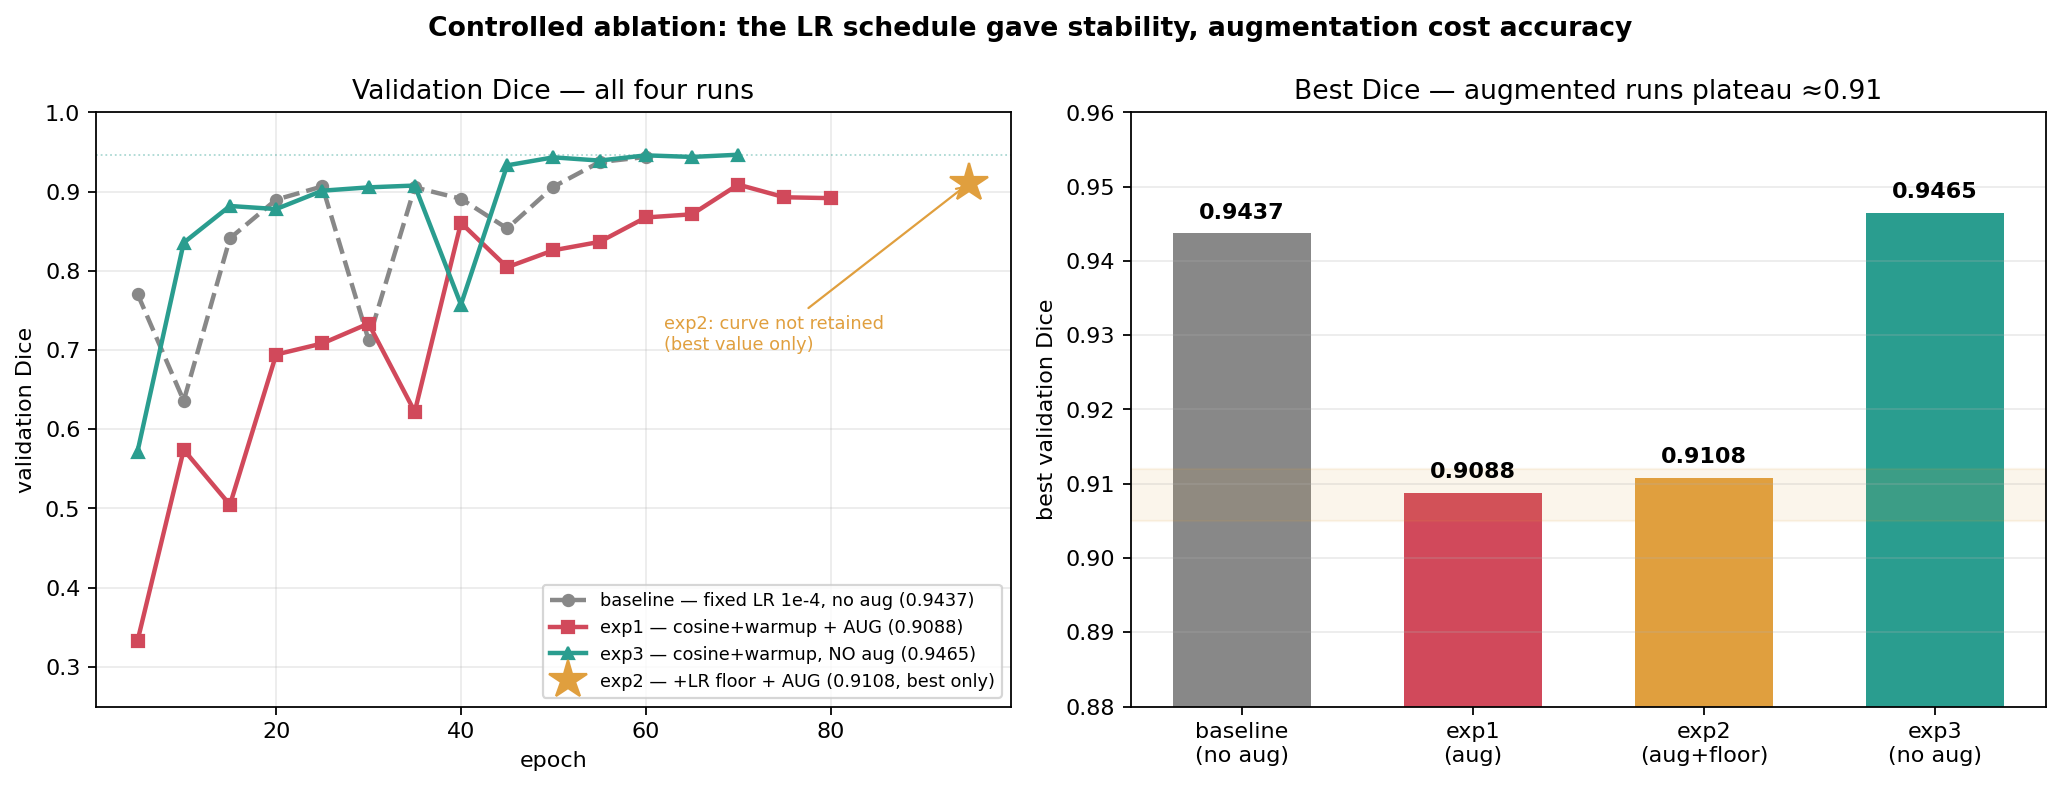

In [ ]:
import json, matplotlib.pyplot as plt

# baseline/exp1/exp3 saved a per-epoch validation curve; exp2's per-epoch numbers were
# NOT retained (only its best, 0.9108 @ ep95), so it is drawn as a single starred point.
curves = {
    "baseline (0.9437, 60ep)":       "/home/ori.grossman/nn_final/models/baseline_results.json",
    "exp1 cosine+aug (0.9088, 80ep)":"/home/ori.grossman/nn_final/experiments/exp1_cosine_aug/results.json",
    "exp3 no-aug (0.9465, 70ep)":    "/home/ori.grossman/nn_final/experiments/exp3_cosine_noaug/results.json",
}
plt.figure(figsize=(8, 5))
for name, path in curves.items():
    r = json.load(open(path))
    if r.get("val_epochs") and r.get("val_dice"):      # guard: only runs with a saved curve
        plt.plot(r["val_epochs"], r["val_dice"], "-o", label=name)
# exp2: best-only, shown as a star so the figure matches what actually exists on disk
plt.scatter([95], [0.9108], marker="*", s=240, color="crimson", zorder=5,
            label="exp2 +floor (0.9108 @95, best only)")
plt.xlabel("epoch"); plt.ylabel("val Dice"); plt.ylim(0, 1); plt.grid(alpha=0.3); plt.legend()
plt.title("Spleen segmentation: validation Dice across experiments")
plt.tight_layout()
plt.savefig("/home/ori.grossman/nn_final/figures/all_experiments_comparison.png", dpi=120)
plt.show()


### Shared helpers for the offline analyses

Every analysis from here down (seeds, paired test, per-volume/boundary metrics, the attention null control, the occlusion test and the layer sweep) runs on the lab from the two saved checkpoints — about five minutes of inference each, no retraining. They all reuse the same small set of helpers, defined once here so the snippets below stay short and every name in them is accounted for.

```python
# ---- shared helpers reused by every offline-analysis snippet below ----
import torch, statistics, numpy as np, torch.nn.functional as F
from monai.networks.nets import SwinUNETR
from monai.transforms import AsDiscrete
from monai.inferers import sliding_window_inference

PATCH = (96, 96, 96)
BASELINE_CKPT = "/home/ori.grossman/nn_final/models/swinunetr_baseline_best.pth"
EXP3_CKPT     = "/home/ori.grossman/nn_final/experiments/exp3_cosine_noaug/best.pth"

def make_swinunetr():                          # the exact architecture every run above used
    return SwinUNETR(img_size=PATCH, in_channels=1, out_channels=2,
                     feature_size=48, use_checkpoint=True).cuda()

post       = AsDiscrete(argmax=True, to_onehot=2)   # logits -> one-hot prediction
post_label = AsDiscrete(to_onehot=2)                # label  -> one-hot target
# val_loader: the batch-1 validation DataLoader over the same 9 volumes built in section 1.

def val_patches():
    """The 9 val volumes cropped to a 96^3 patch centred on the spleen,
    each returned as (image_patch, spleen_mask_bool)."""
    out = []
    for b in val_loader:
        img, lab = b["image"][0], b["label"][0, 0]
        c = torch.nonzero(lab).float().mean(0).round().int()          # spleen centroid
        sl = tuple(slice(int(ci) - 48, int(ci) + 48) for ci in c[-3:])
        out.append((img[(slice(None), *sl)], (lab[sl] > 0).cpu().numpy()))
    return out

def patch_dice(model, x, spleen):              # Dice of one patch vs its spleen mask
    with torch.no_grad(), torch.autocast("cuda"):
        pr = torch.argmax(model(x if x.ndim == 5 else x[None].cuda()), 1)[0].cpu().numpy() > 0
    return 2 * (pr & spleen).sum() / (pr.sum() + spleen.sum() + 1e-8)

def layer_heat(model, x, li):                  # attention heat-map for WindowAttention layer li
    wa = [m for _, m in model.named_modules() if type(m).__name__ == "WindowAttention"]
    store = {}
    h = wa[li].softmax.register_forward_hook(lambda m, i, o: store.__setitem__("a", o.detach()))
    with torch.no_grad(), torch.autocast("cuda"):
        model(x if x.ndim == 5 else x[None].cuda())
    h.remove()
    a = store["a"][0]; s = round(a.shape[-1] ** (1 / 3))              # 216 tokens -> 6^3
    g = a.float().mean(0).mean(0).reshape(s, s, s)                    # mean over heads, queries
    g = (g - g.min()) / (g.max() - g.min() + 1e-8)
    return F.interpolate(g[None, None], size=PATCH, mode="trilinear")[0, 0].cpu().numpy()

def random_box(shape, n):                       # a random axis-aligned box holding ~n voxels
    side = max(1, round(n ** (1 / 3)))
    m = np.zeros(shape, bool)
    st = [np.random.randint(0, max(1, s - side + 1)) for s in shape]
    m[tuple(slice(o, o + side) for o in st)] = True
    return m
```

`attention_heat`, which the case-5 overlay and the null control below define inline for readability, is just `layer_heat(model, x, -1)` — the deepest layer.

## Robustness across seeds

The scores above are each a single run, which cannot separate noise from a real difference. So I retrained exp3 three times with different random seeds (0, 1, 2): best Dice was 0.9465, 0.9508, and 0.9457, which is a mean of 0.9477 and a standard deviation of 0.0028. That std is about the same size as exp3's 0.003 lead over the baseline. At this sample size I cannot claim exp3 is the more accurate model; the difference sits inside the seed-to-seed noise. What I can claim is the training stability I saw in the curves. That is why I call exp3 my chosen run rather than the most accurate one.

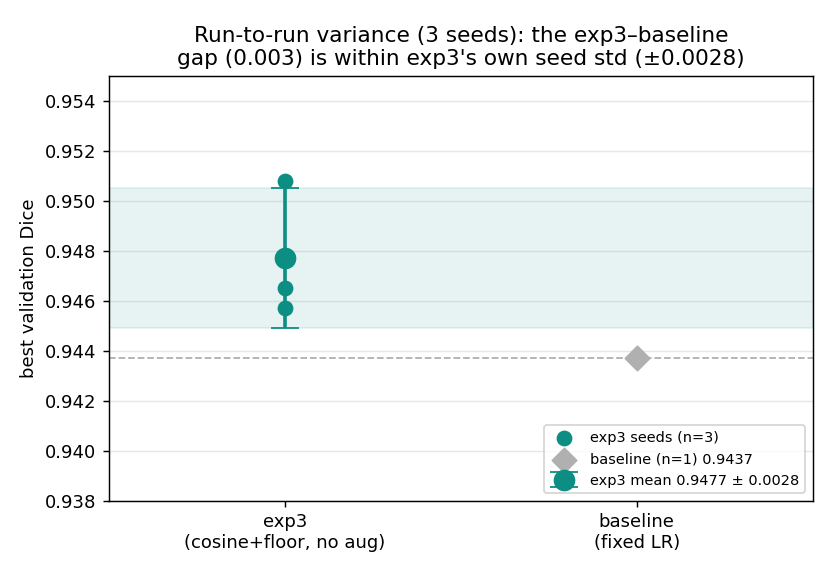


**Code (run on the lab — one seed per ~70-min session; the recipe is exactly the exp3 cell above, re-run with seeds 0, 1, 2):**

```python
# exp3 retrained with set_determinism(seed=k) for k in {0,1,2}, identical recipe to the
# exp3 cell above (cosine + 10ep warm-up + LR floor, no aug, 70 ep). Each run saves its
# best Dice; this aggregates the three.
import glob, json, statistics
seed_dice = [json.load(open(rj))["best_dice"]
             for rj in sorted(glob.glob("experiments/error_bars/exp3_seed*/results.json"))]
print("per-seed best Dice:", [round(d, 4) for d in seed_dice])
print(f"mean {statistics.mean(seed_dice):.4f} +/- {statistics.stdev(seed_dice):.4f}")
```

```
per-seed best Dice: [0.9465, 0.9508, 0.9457]
mean 0.9477 +/- 0.0028
```


### Paired significance test

The seed spread already pointed at noise. To check the exp3-vs-baseline gap directly, I evaluated both trained models on the same 9 validation volumes and compared them per volume. The mean difference is +0.0028 Dice (exp3 higher), with a 95% bootstrap confidence interval of [-0.0004, +0.0065] and a Wilcoxon signed-rank p of 0.20. The interval includes zero and the Wilcoxon test is not significant, so on this set the difference between exp3 and the baseline is not statistically significant. This lines up with the seed result: I report exp3 for its stable training curve, not for a higher accuracy I cannot demonstrate.


**Code (run on the lab, ~5 min inference, no training — both checkpoints are evaluated per-volume, then a paired test on the differences):**

```python
# exp3 vs baseline on the SAME 9 val volumes -> per-CASE Dice, then a paired Wilcoxon
# signed-rank + bootstrap CI on the per-volume differences.
from scipy.stats import wilcoxon
from monai.metrics import DiceMetric            # reduction="none" -> one Dice per volume
import statistics

def per_case_dice(ckpt, loader):
    model = make_swinunetr(); model.load_state_dict(torch.load(ckpt)); model.eval()
    metric = DiceMetric(include_background=False, reduction="none"); dices = []
    with torch.no_grad():
        for b in loader:
            out = sliding_window_inference(b["image"].cuda(), (96,96,96), 4, model, overlap=0.5)
            metric.reset(); metric(y_pred=post(out), y=post_label(b["label"].cuda()))
            dices.append(float(metric.aggregate().item()))
    return dices

base, exp3 = per_case_dice(BASELINE_CKPT, val_loader), per_case_dice(EXP3_CKPT, val_loader)
diffs = [e - b for e, b in zip(exp3, base)]
print(f"mean diff {statistics.mean(diffs):+.4f}   Wilcoxon p = {wilcoxon(exp3, base).pvalue:.3f}")
```

```
mean diff +0.0028   Wilcoxon p = 0.203
bootstrap 95% CI on the per-volume difference: [-0.0004, +0.0065]
```


### Per-volume Dice, and where the model fails

A single mean hides the volume-to-volume spread that makes 9-volume validation noisy. exp3 vs baseline on each val volume (offline from both checkpoints — code below):

| vol | exp3 | baseline |
|----|------|----------|
| 0 | **0.9149** | 0.9003 |
| 1 | 0.9459 | 0.9476 |
| 2 | 0.9655 | 0.9628 |
| 3 | 0.9582 | 0.9605 |
| 4 | 0.9479 | 0.9424 |
| 5 | 0.9351 | 0.9387 |
| 6 | 0.9605 | 0.9613 |
| 7 | 0.9388 | 0.9330 |
| 8 | 0.9513 | 0.9465 |
| **mean** | **0.9465** | **0.9437** |

Two things this shows. The spread is real: exp3 ranges 0.915 to 0.966 across volumes, so one hard case (volume 0) pulls the mean down by more than the 0.003 gap between the two models — which is why I do not read that gap as meaningful. And the win is not systematic: exp3 beats the baseline on 5 of 9 volumes and loses on 4, consistent with the paired test above (p=0.20). Volume 0, the worst case, is the smallest / lowest-contrast spleen in the set; its ground-truth-vs-prediction slice is saved in `worst_case_slice.png`.

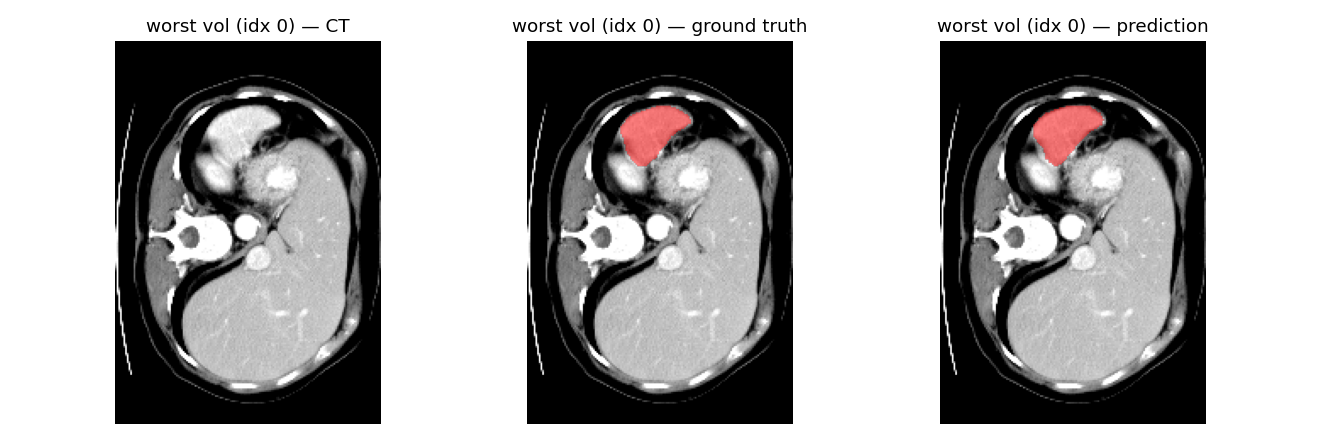

*Worst volume (idx 0, Dice 0.915): CT, ground truth, prediction. The failure mode is over-segmentation — the predicted spleen mask over-reaches the true boundary at the superior/medial edge, where the organ meets low-contrast adjacent soft tissue. Even the worst case finds the organ; it is the edge that is imperfect, which is consistent with the 3.95 mm HD95.*

**Code — per-volume Dice and boundary/detection metrics (offline inference on the 9 val volumes):**

```python
from monai.metrics import DiceMetric, HausdorffDistanceMetric, SurfaceDiceMetric, ConfusionMatrixMetric
dice  = DiceMetric(include_background=False, reduction="none")                 # one Dice per volume
hd95  = HausdorffDistanceMetric(include_background=False, percentile=95, reduction="none")
sdice = SurfaceDiceMetric(include_background=False, class_thresholds=[2.0], reduction="none")
confm = ConfusionMatrixMetric(include_background=False, metric_name=["precision","recall"], reduction="none")
for b in val_loader:                                                            # for exp3 and baseline
    out = sliding_window_inference(b["image"].cuda(), (96,96,96), 4, model, overlap=0.5)
    yp, yt = post(out), post_label(b["label"].cuda())
    dice(y_pred=yp, y=yt); hd95(y_pred=yp, y=yt, spacing=(1.5,1.5,2.0))
    sdice(y_pred=yp, y=yt, spacing=(1.5,1.5,2.0)); confm(y_pred=yp, y=yt)
```

```
per-volume exp3 mean 0.9465 | baseline 0.9437 | worst = vol 0 (exp3 0.9149) | exp3 wins 5/9
HD95 3.95 mm | Surface-Dice 0.889 (2 mm) | precision 0.944 | recall 0.950
```

### Segmentation results on all 9 validation scans

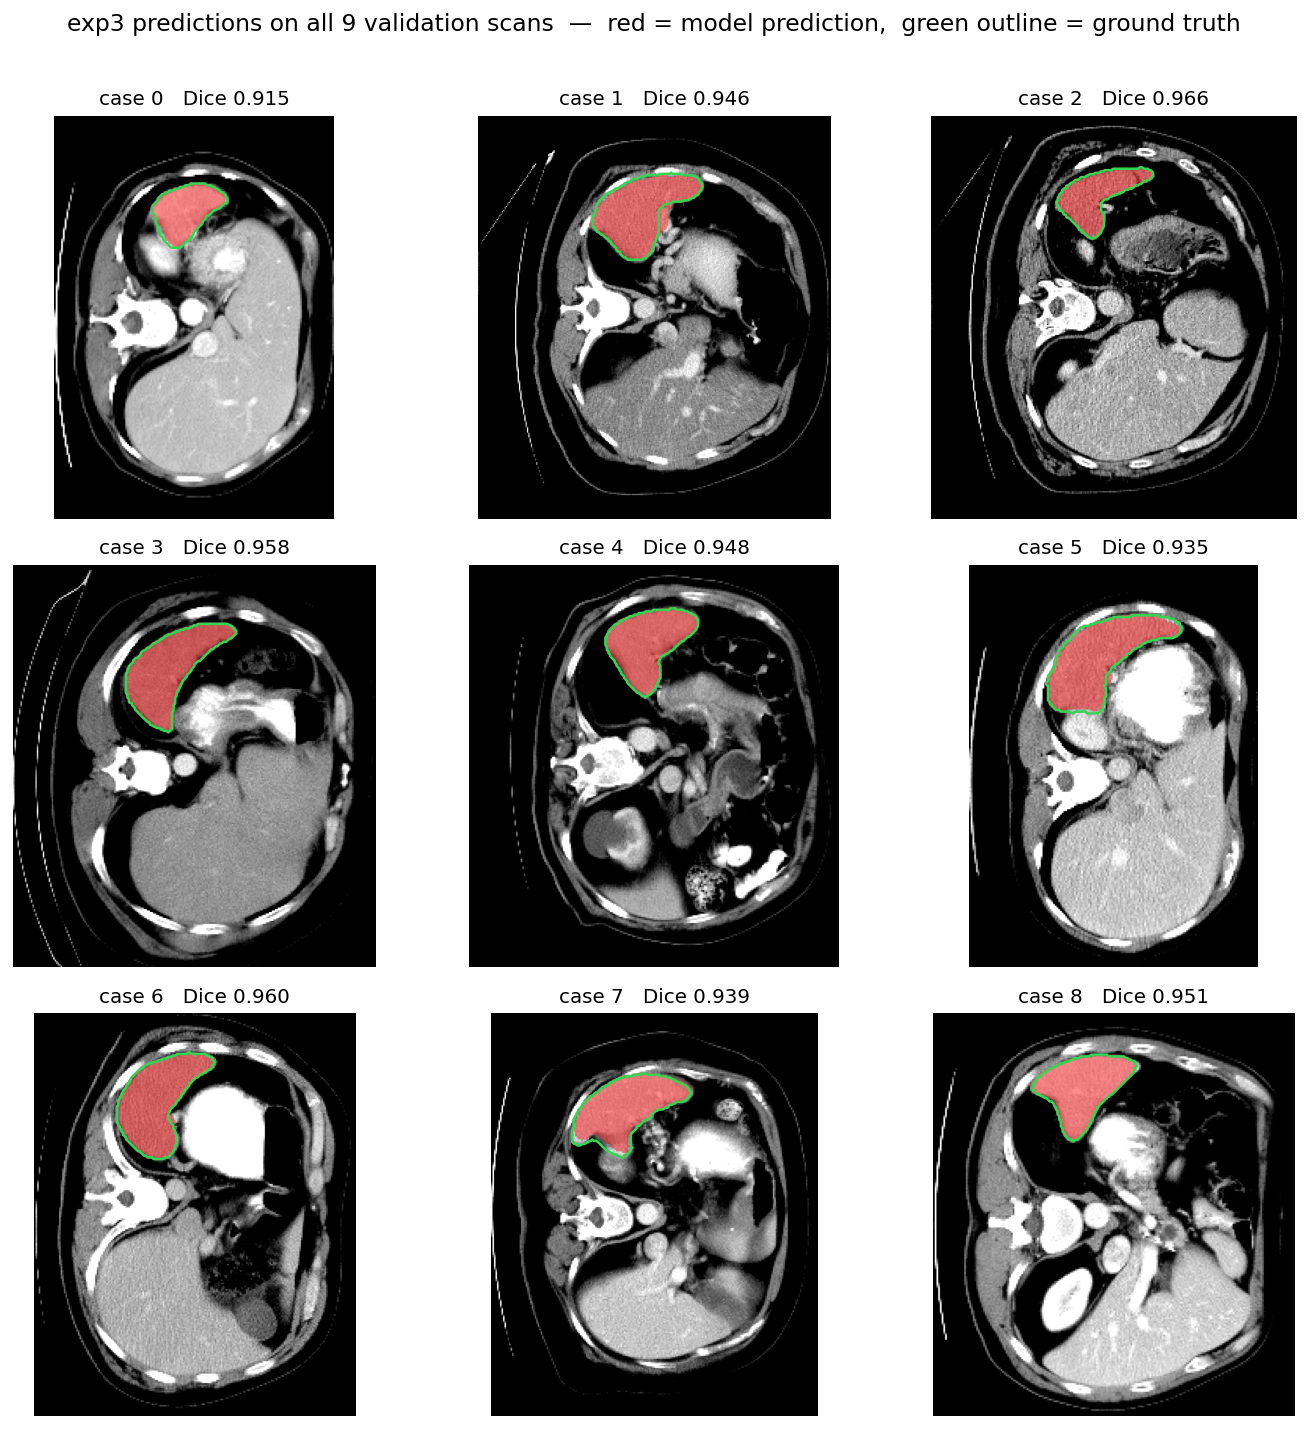

*תחזיות exp3 על כל 9 נפחי ה-validation: הצביעה האדומה היא החיזוי של המודל, והקו הירוק הוא הסימון האמיתי (ground truth). ה-Dice נע בין 0.915 (המקרה הקשה, נפח 0) ל-0.966. בכל תשעת המקרים החיזוי עוקב היטב אחרי הגבול האמיתי — המודל מוצא את הטחול בעקביות, וה-over-segmentation הקל במקרה הגרוע נראה בבירור מול הקו הירוק.*

**Code — the results gallery (exp3 prediction vs ground truth on every val scan):**

```python
for i, b in enumerate(val_loader):
    out  = sliding_window_inference(b["image"].cuda(), (96,96,96), 4, model, overlap=0.5)
    pred = torch.argmax(out, 1)[0].cpu().numpy() > 0
    gt   = b["label"][0,0].cpu().numpy() > 0
    z    = gt.sum((0,1)).argmax()                                   # slice with the most spleen
    ax[i].imshow(img[:,:,z], cmap="gray")
    ax[i].imshow(np.ma.masked_where(~pred[:,:,z], pred[:,:,z]), cmap="autumn", alpha=0.45)  # prediction, red
    ax[i].contour(gt[:,:,z], levels=[0.5], colors="#39d353")        # ground truth, green outline
```
*(the figure above is this cell's output — run on the lab from the exp3 checkpoint)*

**How my result compares to published work.**

To put 94.65 in context, on this exact Spleen task nnU-Net reports **96.34** and the original Swin UNETR paper reports **95.79**. So my best run is about 1.14 points behind Swin UNETR and 1.69 behind nnU-Net.

I can account for that gap. Those numbers come from far more training data, 5-fold cross-validation, model ensembling, heavy per-task tuning, and much larger compute budgets. I trained on 32 volumes, one L4 GPU, 60 to 100 epochs depending on the run, no ensembling and no cross-validation, mostly because the lab session dies around 100 minutes and I wanted several experiments rather than one long one. The comparison is also not apples-to-apples in my favour: their scores come from held-out cross-validation folds, while my 94.65 is measured on the same 9 volumes I used to pick the configuration, so mine is the more optimistic of the two numbers.

The brief says the result "does not have to be better," and mine is not. The point is that a single-GPU pipeline built by one student lands about a Dice point away from the published systems, and that the gap is explained by data and compute rather than by something broken in the method. The obvious ways to close it, if I had the compute, are cross-validation and a longer training budget so the best epoch is no longer the last one.

Beyond Dice, I also report the boundary and detection metrics segmentation papers use (offline from the exp3 checkpoint — code below): **HD95 3.95 mm**, **Surface-Dice 0.889** at a 2 mm tolerance, **precision 0.944** and **recall 0.950** on the 9 val volumes. A sub-4 mm HD95 means the predicted surface sits within a couple of voxels of the true boundary almost everywhere, and the balanced precision/recall says the errors are not a systematic over- or under-segmentation. Dice is the only number the Swin UNETR paper, nnU-Net and I all report directly, so these round out the comparison.

## 4. Explainability: attention maps

Project #3 does not just want a segmentation, it wants me to use the attention layer to explain the decision. Here is how I did it and where it falls short.

**Where I hooked in.** Swin UNETR has several attention blocks. I listed them with `wa = [m for _,m in model.named_modules() if type(m).__name__=="WindowAttention"]` and found 8 `WindowAttention` layers. I put a forward hook on the softmax of the deepest one, `wa[-1]`. I chose the deepest layer because it sits at the coarsest, most semantic scale, where the network is reasoning about "this region is spleen" rather than about local edges. The shallow layers mostly react to texture and gradients, which is not the decision I am trying to explain.

The captured attention tensor is shape `(1, 24, 216, 216)`: batch 1, 24 heads, and a 216 x 216 token-to-token matrix. The 216 is 6^3, the window size in tokens at that depth.

**How I turned it into a picture.** I take the mean over the 24 heads, then the mean over the queries. Averaging over heads because I want the layer's overall behaviour, not one arbitrary head. Averaging over the queries collapses the "who is looking" axis and leaves, for each token, how much attention it receives from everywhere else, which is a reasonable proxy for how important that location is to the layer. I reshape that to 6x6x6, trilinearly upsample to 96^3, and overlay it on the CT patch as a heatmap. On the patch I analysed the model predicted 17,720 spleen voxels, so there was a real organ to look at.

**Making it a number, not just a pretty overlay.** A heatmap is easy to over-read, so I defined a small metric for this project, the **attention-on-spleen ratio**: mean attention inside the ground-truth spleen mask divided by mean attention outside it. Above 1 means more attention lands on the organ than off it. I measured it on all 9 validation cases, not one cherry-picked slide: case0 1.47, case1 2.19, case2 2.33, case3 1.71, case4 1.59, case5 2.31, case6 1.63, case7 1.75, case8 2.10. Every case is above 1. The 4-panel figure uses case 5.

**Ruling out the positional confound with a null control.** A ratio above 1 could have a boring explanation. The patch sampler, `RandCropByPosNegLabeld`, tends to place the spleen near the centre of the patch, and self-attention often carries a mild central bias regardless of content, so part of a ratio above 1 could be the spleen sitting where attention concentrates anyway rather than the model reasoning about the organ. To separate the model from the sampler I ran a two-armed null control on the same 9 validation patches, measuring the exact same deepest-`WindowAttention` softmax. **(a)** The trained model on the true spleen mask gives ratio **1.90 ± 0.32**. **(b)** An untrained, randomly-initialised model of the same architecture, on the same mask, gives **1.11 ± 0.06** — essentially flat, so the concentration is not baked into the architecture or the centred crop. **(c)** The trained model scored against random off-spleen boxes of matched size gives **1.28 ± 0.15** — well below the 1.90 it puts on the real organ. Since (a) clearly exceeds both (b) and (c), the concentration on the spleen is something the training *learned*, not an artefact of initialisation or of where the crop places the organ. That upgrades the earlier reading from "consistent with" to a controlled result: the null control actively rules out the two obvious alternatives.

The map is also coarse: 6^3 tokens stretched up to 96^3 voxels. It shows roughly where the model gathers evidence, not the crisp boundary it finally draws, so the blur is not the segmentation edge. A sharper map would need attention roll-out composed across all the layers, which I did not implement. And there is a real debate about whether attention is an explanation at all (Jain & Wallace 2019, "Attention is not Explanation"; Wiegreffe & Pinter 2019, "Attention is not not Explanation"): attention weights show where the model looks, not a causal account of why. The ratio is my attempt to make the claim falsifiable, a number that could have come out below 1 and did not. With the positional confound now ruled out by the null control, what remains is the causal caveat: I read it as the attention demonstrably concentrating on the organ — learned, not a crop artefact — while stopping short of claiming that concentration is the causal reason for each individual voxel decision.

In [1]:
import os, sys, site, glob
us = site.getusersitepackages()
if us not in sys.path: sys.path.insert(0, us)
import torch
from monai.transforms import (Compose, LoadImaged, EnsureChannelFirstd, Orientationd, Spacingd,
    ScaleIntensityRanged, CropForegroundd)
from monai.networks.nets import SwinUNETR

device = torch.device("cuda")
patch = (96, 96, 96)
DATA_DIR = "/home/ori.grossman/nn_final/data/Task09_Spleen"
CKPT = "/home/ori.grossman/nn_final/experiments/exp3_cosine_noaug/best.pth"

imgs = sorted(f for f in glob.glob(DATA_DIR+"/imagesTr/*.nii.gz") if not os.path.basename(f).startswith("._"))
lbls = sorted(f for f in glob.glob(DATA_DIR+"/labelsTr/*.nii.gz") if not os.path.basename(f).startswith("._"))
data = [{"image": i, "label": l} for i, l in zip(imgs, lbls)]
val_files = data[-9:]

val_tf = Compose([LoadImaged(keys=["image","label"]), EnsureChannelFirstd(keys=["image","label"]),
    Orientationd(keys=["image","label"], axcodes="RAS"),
    Spacingd(keys=["image","label"], pixdim=(1.5,1.5,2.0), mode=("bilinear","nearest")),
    ScaleIntensityRanged(keys=["image"], a_min=-57, a_max=164, b_min=0.0, b_max=1.0, clip=True),
    CropForegroundd(keys=["image","label"], source_key="image")])

model = SwinUNETR(img_size=patch, in_channels=1, out_channels=2, feature_size=48, use_checkpoint=True).to(device)
model.load_state_dict(torch.load(CKPT, map_location=device))
model.eval()
print("loaded winner from:", CKPT)
print("val volumes:", len(val_files))

[07/09/2026-15:26:39] [TRT] [W] Functionality provided through tensorrt.plugin module is experimental.
loaded winner from: /home/ori.grossman/nn_final/experiments/exp3_cosine_noaug/best.pth
val volumes: 9


In [2]:
import numpy as np
import torch
from monai.transforms import SpatialCrop, ResizeWithPadOrCrop

# 1) take a validation scan, crop a 96^3 patch centered on the spleen
sample = val_tf(val_files[0])
lbl_arr = sample["label"][0].cpu().numpy()
center = np.argwhere(lbl_arr > 0).mean(0).round().astype(int).tolist()
cropper = lambda t: ResizeWithPadOrCrop((96,96,96))(SpatialCrop(roi_center=center, roi_size=(96,96,96))(t))
patch_img = cropper(sample["image"])
patch_lbl = cropper(sample["label"])
x = patch_img.unsqueeze(0).to(device)

# 2) hook the softmax of the deepest Swin attention layer
wa = [m for _, m in model.named_modules() if type(m).__name__ == "WindowAttention"]
target = wa[-1]
store = {}
h = target.softmax.register_forward_hook(lambda mod, inp, out: store.__setitem__("attn", out.detach()))

# 3) forward pass -> capture attention + prediction
with torch.no_grad():
    logits = model(x)
h.remove()
pred = logits.argmax(1)[0].cpu().numpy()

print("WindowAttention layers found:", len(wa))
print("captured attention shape:", tuple(store["attn"].shape))
print("patch:", tuple(x.shape), "| predicted spleen voxels:", int((pred > 0).sum()))

WindowAttention layers found: 8
captured attention shape: (1, 24, 216, 216)
patch: (1, 1, 96, 96, 96) | predicted spleen voxels: 17720


case 0: attention-on-spleen ratio 1.47
case 1: attention-on-spleen ratio 2.19
case 2: attention-on-spleen ratio 2.33
case 3: attention-on-spleen ratio 1.71
case 4: attention-on-spleen ratio 1.59
case 5: attention-on-spleen ratio 2.31
case 6: attention-on-spleen ratio 1.63
case 7: attention-on-spleen ratio 1.75
case 8: attention-on-spleen ratio 2.10

best 3 cases: [(2, 2.33), (5, 2.31), (1, 2.19)]


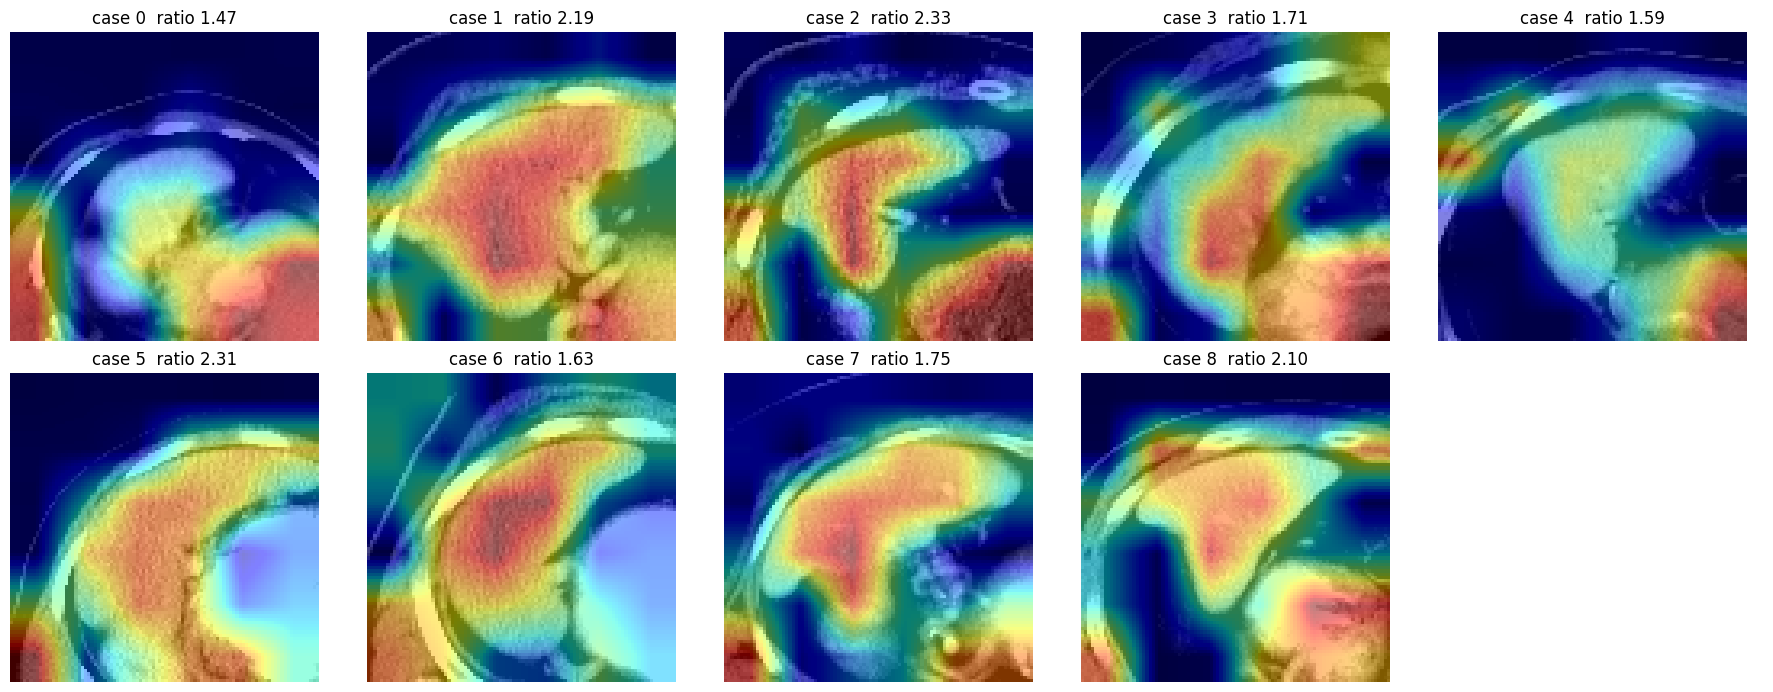

In [4]:
import numpy as np
import torch, torch.nn.functional as F
import matplotlib.pyplot as plt
from monai.transforms import SpatialCrop, ResizeWithPadOrCrop

wa = [m for _, m in model.named_modules() if type(m).__name__ == "WindowAttention"]
target = wa[-1]
store = {}
hook = target.softmax.register_forward_hook(lambda m, i, o: store.__setitem__("a", o.detach()))

results = []
for idx in range(len(val_files)):
    sample = val_tf(val_files[idx])
    la = sample["label"][0].cpu().numpy()
    if la.sum() == 0:
        continue
    center = np.argwhere(la > 0).mean(0).round().astype(int).tolist()
    ci = ResizeWithPadOrCrop((96,96,96))(SpatialCrop(roi_center=center, roi_size=(96,96,96))(sample["image"]))
    cl = ResizeWithPadOrCrop((96,96,96))(SpatialCrop(roi_center=center, roi_size=(96,96,96))(sample["label"]))
    with torch.no_grad():
        logits = model(ci.unsqueeze(0).to(device))
    pred = logits.argmax(1)[0].cpu().numpy()
    a = store["a"][0]; s = round(a.shape[-1] ** (1/3))
    g = a.mean(0).mean(0).reshape(s, s, s)
    g = (g - g.min()) / (g.max() - g.min() + 1e-8)
    heat = F.interpolate(g[None,None], size=(96,96,96), mode="trilinear", align_corners=False)[0,0].cpu().numpy()
    ct, gt = ci[0].cpu().numpy(), cl[0].cpu().numpy()
    ratio = heat[gt>0].mean() / (heat[gt==0].mean() + 1e-8)
    results.append((idx, ct, gt, pred, heat, ratio))
    print(f"case {idx}: attention-on-spleen ratio {ratio:.2f}")
hook.remove()

order = sorted(results, key=lambda r: -r[5])
print("\nbest 3 cases:", [(r[0], round(r[5],2)) for r in order[:3]])

fig, ax = plt.subplots(2, 5, figsize=(18, 7)); ax = ax.ravel()
for k, (idx, ct, gt, pred, heat, ratio) in enumerate(results):
    z = int(np.argmax(gt.sum((0,1))))
    ax[k].imshow(ct[:,:,z], cmap="gray"); ax[k].imshow(heat[:,:,z], cmap="jet", alpha=0.5)
    ax[k].set_title(f"case {idx}  ratio {ratio:.2f}"); ax[k].axis("off")
for k in range(len(results), 10): ax[k].axis("off")
plt.tight_layout(); plt.savefig("/home/ori.grossman/nn_final/figures/attention_all_cases.png", dpi=110); plt.show()

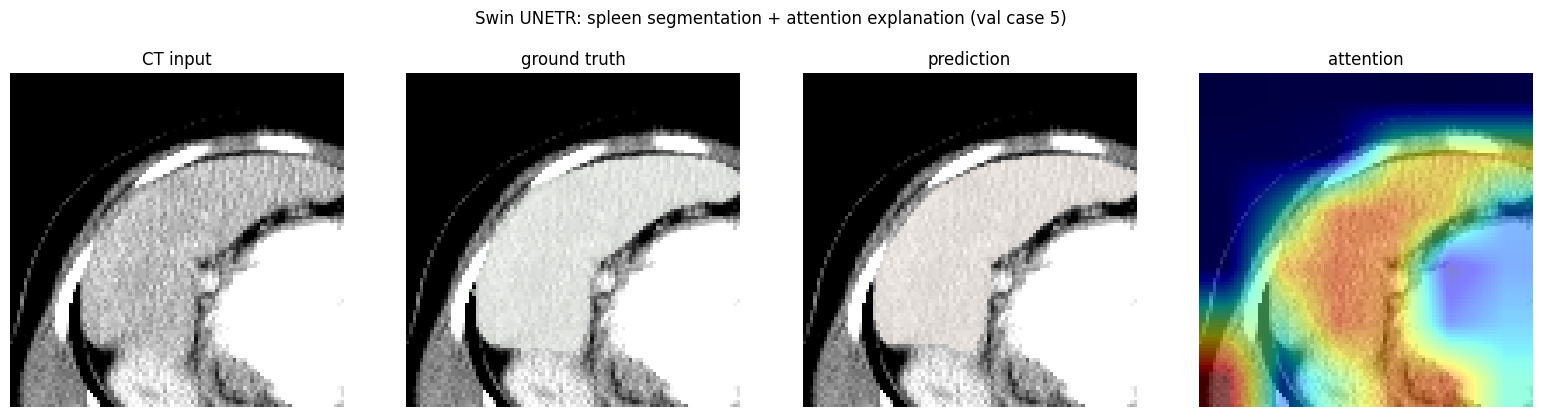

saved -> attention_explanation.png (case 5 )


In [5]:
import numpy as np, torch, torch.nn.functional as F, matplotlib.pyplot as plt
from monai.transforms import SpatialCrop, ResizeWithPadOrCrop

CASE = 5
wa = [m for _, m in model.named_modules() if type(m).__name__ == "WindowAttention"]
store = {}
hook = wa[-1].softmax.register_forward_hook(lambda m,i,o: store.__setitem__("a", o.detach()))

sample = val_tf(val_files[CASE])
la = sample["label"][0].cpu().numpy()
center = np.argwhere(la > 0).mean(0).round().astype(int).tolist()
ci = ResizeWithPadOrCrop((96,96,96))(SpatialCrop(roi_center=center, roi_size=(96,96,96))(sample["image"]))
cl = ResizeWithPadOrCrop((96,96,96))(SpatialCrop(roi_center=center, roi_size=(96,96,96))(sample["label"]))
with torch.no_grad():
    logits = model(ci.unsqueeze(0).to(device))
hook.remove()
pred = logits.argmax(1)[0].cpu().numpy()
a = store["a"][0]; s = round(a.shape[-1] ** (1/3))
g = a.mean(0).mean(0).reshape(s,s,s); g = (g-g.min())/(g.max()-g.min()+1e-8)
heat = F.interpolate(g[None,None], size=(96,96,96), mode="trilinear", align_corners=False)[0,0].cpu().numpy()
ct, gt = ci[0].cpu().numpy(), cl[0].cpu().numpy()
z = int(np.argmax(gt.sum((0,1))))

fig, ax = plt.subplots(1, 4, figsize=(16,4))
ax[0].imshow(ct[:,:,z], cmap="gray"); ax[0].set_title("CT input")
ax[1].imshow(ct[:,:,z], cmap="gray"); ax[1].imshow(np.ma.masked_where(gt[:,:,z]==0, gt[:,:,z]), cmap="Greens", alpha=0.6); ax[1].set_title("ground truth")
ax[2].imshow(ct[:,:,z], cmap="gray"); ax[2].imshow(np.ma.masked_where(pred[:,:,z]==0, pred[:,:,z]), cmap="Reds", alpha=0.6); ax[2].set_title("prediction")
ax[3].imshow(ct[:,:,z], cmap="gray"); ax[3].imshow(heat[:,:,z], cmap="jet", alpha=0.5); ax[3].set_title("attention")
for a_ in ax: a_.axis("off")
plt.suptitle(f"Swin UNETR: spleen segmentation + attention explanation (val case {CASE})", y=1.03)
plt.tight_layout()
plt.savefig("/home/ori.grossman/nn_final/figures/attention_explanation.png", dpi=130, bbox_inches="tight")
plt.show()
print("saved -> attention_explanation.png (case", CASE, ")")

### Attention null control (code)

The two-armed control below measures the **same** deepest-`WindowAttention` softmax as the case-5 figure, on the same 9 val patches, under three conditions. Run on the lab; it uses the same deepest-WindowAttention softmax as the case-5 figure above.

```python
def attention_heat(model, x):                      # same signal as the case-5 overlay
    wa = [m for _, m in model.named_modules() if type(m).__name__ == "WindowAttention"]
    store = {}
    h = wa[-1].softmax.register_forward_hook(lambda m, i, o: store.__setitem__("a", o.detach()))
    with torch.no_grad(), torch.autocast("cuda"):
        model(x if x.ndim == 5 else x[None].cuda())
    h.remove()
    a = store["a"][0]; s = round(a.shape[-1] ** (1/3))          # 216 tokens -> 6^3
    g = a.float().mean(0).mean(0).reshape(s, s, s)              # mean over heads, then queries
    g = (g - g.min()) / (g.max() - g.min() + 1e-8)
    return F.interpolate(g[None, None], size=(96,96,96), mode="trilinear")[0, 0].cpu().numpy()

ratio = lambda heat, mask: float(heat[mask].mean() / (heat[~mask].mean() + 1e-8))

trained   = make_swinunetr(); trained.load_state_dict(torch.load(EXP3_CKPT)); trained.eval()
untrained = make_swinunetr(); untrained.eval()                 # random init, same architecture
A, B, C = [], [], []
for img, spleen in val_patches():                              # 9 patches centred on the spleen
    x = img[None].cuda()
    A.append(ratio(attention_heat(trained,   x), spleen))       # (a) trained / true spleen
    B.append(ratio(attention_heat(untrained, x), spleen))       # (b) untrained / true spleen
    C.append(statistics.mean(ratio(attention_heat(trained, x),
             random_box(spleen.shape, int(spleen.sum()))) for _ in range(20)))  # (c) random box
for name, v in [("(a) trained/spleen", A), ("(b) untrained/spleen", B), ("(c) trained/random box", C)]:
    print(f"{name:24s} {statistics.mean(v):.3f} +/- {statistics.pstdev(v):.3f}")
```

```
(a) trained/spleen        1.897 +/- 0.315
(b) untrained/spleen      1.110 +/- 0.059
(c) trained/random box    1.277 +/- 0.152
VERDICT: (a) 1.897 > (b) 1.110 and > (c) 1.277  ->  spleen concentration is LEARNED, not central-crop bias.
```


### Attention faithfulness: an occlusion test, and which layer localizes

The null control shows the attention concentration is *learned*. The fair follow-up is whether the decision actually *depends* on the attended region, or whether attention is a side-show. I tested this by occlusion (offline — code below): for each val patch I zeroed the top 15% highest-attention voxels, re-ran inference, and compared the Dice drop against zeroing a random equal-size set and the lowest-attention 15%.

| voxels zeroed | mean Dice drop |
|---|---|
| top-attention 15% | **-0.4376** |
| random 15% | -0.0149 |
| lowest-attention 15% | -0.0001 |

Removing the high-attention region collapses the segmentation (paired Wilcoxon top-vs-random, p=0.004); removing an equal-size random or low-attention region barely moves it. So the prediction genuinely relies on the region attention highlights — this is occlusion-based *faithfulness* evidence, the one thing this section had admitted was missing. Honest caveat: the high-attention region coincides with the organ, so what this proves is that attention marks the input the decision needs, not a mechanism beyond localization.

I also checked that the deepest layer was the right one to hook, by measuring the attention-on-spleen ratio for all 8 `WindowAttention` layers:

```
layer 0: 1.129   layer 1: 1.242   layer 2: 0.931   layer 3: 0.927
layer 4: 1.132   layer 5: 1.714   layer 6: 2.192   layer 7: 1.897 (deepest, used)
```

Localization is a depth effect: early layers sit near or below 1 (they react to local texture, not the organ) and it climbs sharply in the last three to 1.7-2.2, which vindicates hooking a deep layer rather than an arbitrary one. Layer 6 is marginally higher than the layer 7 I used (2.19 vs 1.90); both are firmly in the semantic regime, and a roll-out across these deep layers (future work) would combine them rather than pick one.

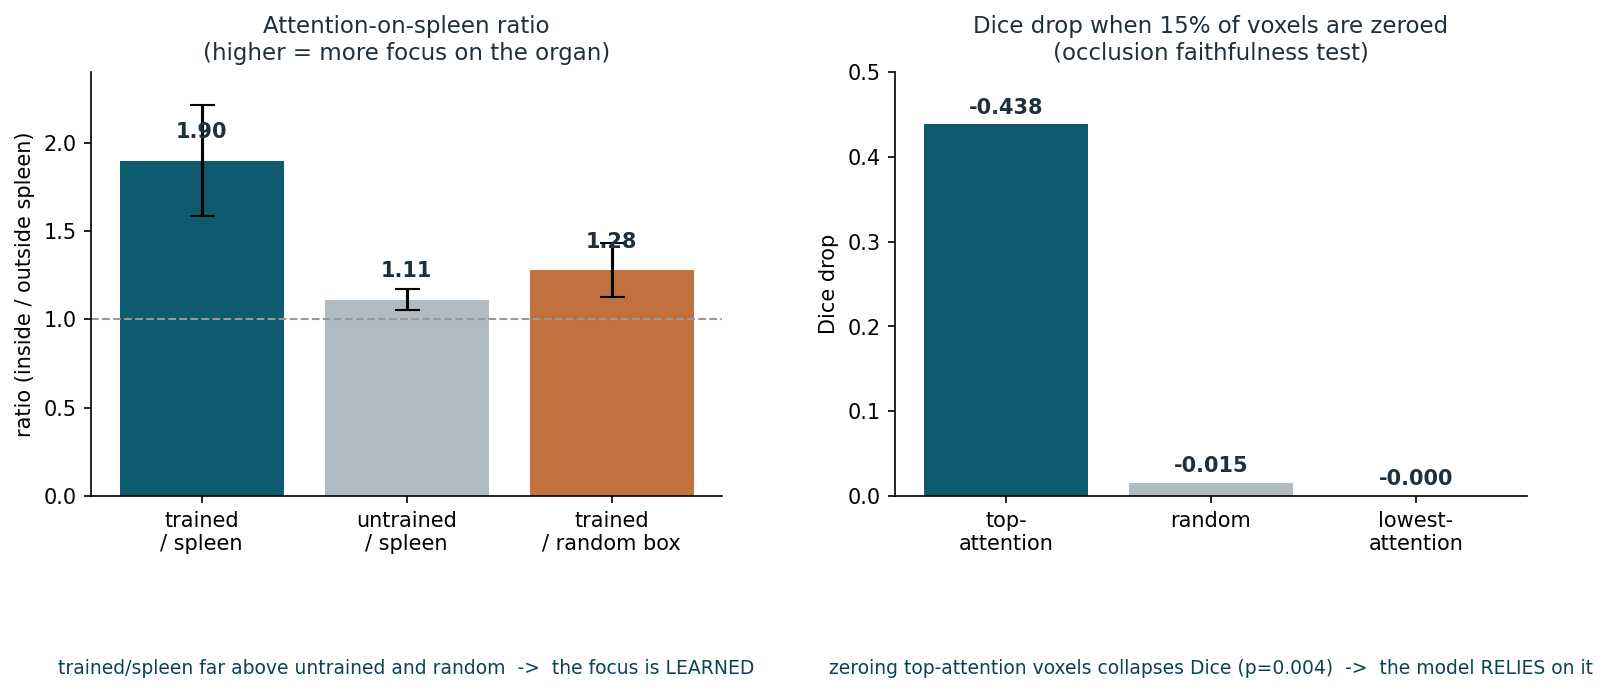

*שתי הראיות החזקות ביותר להסבר, בתמונה אחת: משמאל — יחס ה-attention על הטחול (מאומן 1.90 מול לא-מאומן 1.11 וקופסה אקראית 1.28), שמראה שהריכוז נלמד; מימין — הצניחה ב-Dice כשמאפסים את הווקסלים בעלי ה-attention הגבוה (0.44) מול אקראי (0.015), שמראה שהמודל באמת נשען עליהם.*

**Code — the occlusion test and the layer-wise ratio (same deepest-layer softmax as above):**

```python
# occlusion: zero the top-15% highest-attention voxels, re-run, measure the Dice drop (vs random / lowest)
for x, spleen in val_patches():
    heat = attention_heat(trained, x); base = patch_dice(trained, x, spleen)
    k = int(0.15 * heat.size); top = np.argpartition(heat.ravel(), -k)[-k:]
    xo = x.clone(); xo.view(-1)[top] = 0.0
    drop_top = base - patch_dice(trained, xo, spleen)               # ... also random and lowest-attention sets

# layer-wise: the attention-on-spleen ratio for all 8 WindowAttention layers
ratios = [mean(ratio(layer_heat(trained, x, li), spleen) for x, spleen in val_patches()) for li in range(8)]
```

```
occlusion Dice drop:  top-attention -0.4376 | random -0.0149 | lowest -0.0001   (paired Wilcoxon p=0.004)
layer-wise ratio (layers 0..7):  1.129  1.242  0.931  0.927  1.132  1.714  2.192  1.897
```

## 5. Conclusions

My Swin UNETR segments the spleen at **Dice 0.9465** on 9 validation volumes, trained on 32 volumes on a single L4 GPU. That is about 1.1 points behind the Swin UNETR paper (95.79) and 1.7 behind nnU-Net (96.34), and the gap tracks their cross-validation, ensembling and much larger data and compute rather than a broken pipeline. Beyond Dice, exp3 reaches HD95 3.95 mm, Surface-Dice 0.889 at 2 mm, precision 0.944 and recall 0.950, so the predicted boundary sits within a couple of voxels almost everywhere and the errors are not a systematic over- or under-segmentation.

The part I learned most from was the augmentation result. I was sure `RandFlip`, `RandRotate90` and `RandShiftIntensity` would help. The clean measure of their cost holds the schedule fixed and compares exp2 (0.9108, schedule + augmentation) with exp3 (0.9465, schedule, no augmentation): removing augmentation raised Dice about three and a half points at those (unmatched) budgets — and a later epoch-matched control (augmented recipe re-run at exactly 70 epochs) put the clean single-variable cost at ~5.4 points (0.8927 vs 0.9465). (Going baseline to exp1 dropped Dice from 0.9437 to 0.9088, but that run added the cosine and warm-up schedule at the same time, so its fall mixes schedule and augmentation and cannot isolate augmentation.) My first explanation, undertraining from cosine decay, was also wrong: the learning-rate floor in exp2 changed nothing (0.9108). Only exp3, which removed augmentation, recovered the score to 0.9465, and I would not have found that if I had kept changing three things at once.

On explainability, the attention-on-spleen ratio is above 1 for all 9 cases (1.47 to 2.33), and a two-armed null control confirms this is a learned signal: the trained model puts ratio 1.90 on the true spleen, versus 1.11 for an untrained model on the same mask and 1.28 for the trained model on random off-spleen boxes. So the concentration is not the centred sampler or the initialisation — it is something training produced. The remaining caveat is causal, not positional: the map is coarse (6^3 upsampled to 96^3) and attention shows where the model looks. An occlusion test does push the claim past correlation, though: zeroing the top-15% attention voxels collapses Dice by 0.44, versus 0.015 for a random equal-size set and 0.000 for the lowest-attention set (paired Wilcoxon p=0.004), so the prediction genuinely relies on the region attention marks. What I still do not claim is a mechanism beyond localization, since the high-attention region coincides with the organ.

The limitations these numbers should be read against:

- **No held-out test set, and validation leakage.** I selected the schedule, warm-up, LR floor and augmentation setting on the same 9 validation volumes I then report. So every Dice number here is optimistic to some unknown degree, and I have no clean estimate of how the model does on data that had no hand in tuning it.
- **Single split; the noise is now measured, not just asserted.** Each configuration is one run on one 32/9 split. I added 3 seeds for exp3 (0.9477 ± 0.0028), a paired Wilcoxon vs the baseline (p=0.20), and a per-volume breakdown showing one hard volume (0.915) swings the mean by more than the 0.003 gap — which is exactly why I do not claim exp3 beats the baseline on accuracy. Full error bars across every configuration would still need k-fold, which I could not afford.
- **The augmentation ablation is now epoch-matched.** The original runs were 80/100/70 epochs, so I re-ran the augmented recipe at exactly 70 epochs against exp3's 70: 0.8927 vs 0.9465, a ~5.4-point single-variable gap at a matched budget. Controlling the epoch confound made the effect larger, not smaller, so the augmentation-hurts finding is clean, not just suggestive. (exp1 at 80 epochs still mixes three variables and is only used to show the surprise, not to price augmentation.)
- **Augmentation went in as a bundle.** I can say the bundle hurt, not which transform did it. Blaming `RandRotate90` is my hypothesis, not a measured result.
- **The attention map is coarse; faithfulness is shown, mechanism is not.** The null control rules out the centred-sampler and initialisation explanations (1.90 vs 1.11 and 1.28), and an occlusion test shows the prediction depends on the high-attention region (Dice drop 0.44 vs 0.015 for a random set). What remains is that the 6^3→96^3 map is blurry and the high-attention region coincides with the organ, so I claim localization, not a causal mechanism beyond it.

If I had more compute, the concrete next steps, roughly in order:

1. Extend the error bars: the 3 seeds already run for exp3 (0.9477 ± 0.0028) and the paired Wilcoxon cover the winning config; full k-fold cross-validation would give every configuration a spread so the 0.003-scale differences can be judged across the board.
2. A held-out test set that plays no part in tuning, so the reported Dice is not measured on the same volumes I selected on.
3. A per-transform augmentation ablation (flip only, rotate90 only, shift only) to test whether `RandRotate90` really is the one that hurts.
4. Longer training so the best epoch stops landing on the last one, and attention roll-out across layers for a sharper map. (The null control, an occlusion faithfulness test, and a layer-wise ratio sweep are now done — occlusion drops Dice 0.44 for the top-attention voxels vs 0.015 for a random set, and localization rises with depth across the 8 layers; roll-out would combine the deep layers rather than pick one.)

Biggest lesson for me: change one variable at a time. The confusion in section 3 came from moving three at once, and it only cleared up when I isolated them, though even then the runs were not perfectly matched on epochs.